# Modelización predictiva — Desarrollo y validación interna

El objetivo de este notebook es desarrollar y seleccionar la estrategia de modelización antes de realizar la evaluación temporal externa. El problema predictivo mantiene como variable objetivo principal el `porcentaje_juegos_ganados`, mientras que los predictores utilizados proceden de la selección realizada previamente sobre el conjunto de desarrollo.

La fase de desarrollo comprende las temporadas 2009–2019 y 2022–2023. La temporada 2024 permanece completamente excluida de este notebook y se reservará para una evaluación temporal externa independiente una vez que se hayan fijado las variables, el procedimiento de preprocesamiento, los modelos y sus hiperparámetros.

Para seleccionar y comprobar la estabilidad de las decisiones de modelización se plantea una validación temporal mediante ventanas expansivas. En cada partición, el modelo se entrenará exclusivamente con temporadas anteriores al periodo utilizado como validación. Como propuesta inicial se consideran cinco periodos de validación: 2017, 2018, 2019, 2022 y 2023.

Antes de construir definitivamente estas particiones se comprobará que:

1. el conjunto de desarrollo contiene únicamente las temporadas previstas;
2. cada partido conserva sus dos perspectivas jugador–partido;
3. los periodos propuestos presentan un número adecuado de partidos y torneos;
4. en todos los folds el conjunto de entrenamiento es cronológicamente anterior al de validación.

Las particiones internas forman parte del proceso de desarrollo y podrán utilizarse posteriormente para seleccionar algoritmos, ajustar hiperparámetros y realizar comprobaciones limitadas de variables previamente identificadas como dudosas. No se interpretarán como la evaluación final independiente del modelo, función reservada exclusivamente a la temporada 2024.

In [1]:
import pandas as pd


# ============================================================
# 1. CARGA DEL CONJUNTO DE DESARROLLO
# ============================================================

df_desarrollo = pd.read_csv(
    "df_modelo_principal_365d.csv",
    low_memory=False
)

df_desarrollo["fecha_torneo"] = pd.to_datetime(
    df_desarrollo["fecha_torneo"],
    errors="raise"
)


# ============================================================
# 2. COMPROBACIONES ESTRUCTURALES
# ============================================================

anios_esperados = set(range(2009, 2020)) | {2022, 2023}

assert set(df_desarrollo["match_year"].unique()) == anios_esperados

assert 2024 not in df_desarrollo["match_year"].unique()

assert df_desarrollo["es_desarrollo_modelo"].eq(1).all()

assert (
    df_desarrollo
    .groupby("_id_partido")
    .size()
    .eq(2)
    .all()
)

assert df_desarrollo["porcentaje_juegos_ganados"].notna().all()

assert (
    df_desarrollo["porcentaje_juegos_ganados"]
    .between(0, 1)
    .all()
)

print("Estructura general del conjunto de desarrollo: CORRECTA")


# ============================================================
# 3. RESUMEN POR TEMPORADA
# ============================================================

resumen_temporadas = (
    df_desarrollo
    .groupby("match_year")
    .agg(
        observaciones=("_id_partido", "size"),
        partidos=("_id_partido", "nunique"),
        torneos=("identificador_torneo", "nunique"),
        fecha_min=("fecha_torneo", "min"),
        fecha_max=("fecha_torneo", "max")
    )
)

display(resumen_temporadas)


# ============================================================
# 4. VIABILIDAD DE LOS FOLDS TEMPORALES PROPUESTOS
# ============================================================

folds_propuestos = [
    (1, list(range(2009, 2017)), 2017),
    (2, list(range(2009, 2018)), 2018),
    (3, list(range(2009, 2019)), 2019),
    (4, list(range(2009, 2020)), 2022),
    (5, list(range(2009, 2020)) + [2022], 2023)
]

resumen_folds = []

for fold, anios_train, anio_validacion in folds_propuestos:

    train = df_desarrollo[
        df_desarrollo["match_year"].isin(anios_train)
    ]

    validacion = df_desarrollo[
        df_desarrollo["match_year"].eq(anio_validacion)
    ]

    assert len(train) > 0
    assert len(validacion) > 0

    assert (
        train["fecha_torneo"].max()
        <
        validacion["fecha_torneo"].min()
    )

    assert set(train["_id_partido"]).isdisjoint(
        set(validacion["_id_partido"])
    )

    resumen_folds.append(
        {
            "fold": fold,
            "validacion": anio_validacion,
            "partidos_train": train["_id_partido"].nunique(),
            "partidos_validacion": validacion["_id_partido"].nunique(),
            "torneos_validacion": validacion["identificador_torneo"].nunique(),
            "fecha_max_train": train["fecha_torneo"].max(),
            "fecha_min_validacion": validacion["fecha_torneo"].min()
        }
    )

resumen_folds = pd.DataFrame(resumen_folds)

display(resumen_folds)

print("Viabilidad temporal de los folds propuestos: CORRECTA")

Estructura general del conjunto de desarrollo: CORRECTA


,observaciones,partidos,torneos,fecha_min,fecha_max
match_year,,,,,
2009,5830,2915,142,2009-01-04,2009-12-04
2010,5758,2879,144,2010-01-03,2010-12-03
2011,5774,2887,142,2011-01-02,2011-12-02
2012,5792,2896,145,2012-01-01,2012-11-16
2013,5624,2812,144,2012-12-30,2013-11-15
2014,5556,2778,140,2013-12-29,2014-11-21
2015,5674,2837,144,2015-01-04,2015-11-27
2016,5634,2817,132,2016-01-04,2016-11-25
2017,5612,2806,134,2017-01-02,2017-11-24


,fold,validacion,partidos_train,partidos_validacion,torneos_validacion,fecha_max_train,fecha_min_validacion
0,1,2017,22821,2806,134,2016-11-25,2017-01-02
1,2,2018,25627,2790,135,2017-11-24,2018-01-01
2,3,2019,28417,2738,126,2018-11-23,2018-12-31
3,4,2022,31155,2633,133,2019-11-24,2022-01-10
4,5,2023,33788,2837,137,2022-11-27,2023-01-02


Viabilidad temporal de los folds propuestos: CORRECTA


## Definición de la validación temporal interna

La comprobación de la distribución temporal mostró una estructura estable entre las temporadas consideradas para validación, tanto en número de partidos como de torneos. Por este motivo, se mantienen cinco particiones temporales internas correspondientes a las temporadas 2017, 2018, 2019, 2022 y 2023.

La validación sigue una estrategia de ventana expansiva. En cada partición se utilizan como entrenamiento todas las temporadas analíticas anteriores disponibles, incorporando progresivamente los nuevos periodos una vez que han pasado a formar parte del historial observable.

Las particiones quedan definidas de la siguiente forma:

- Fold 1: entrenamiento 2009–2016 y validación 2017.
- Fold 2: entrenamiento 2009–2017 y validación 2018.
- Fold 3: entrenamiento 2009–2018 y validación 2019.
- Fold 4: entrenamiento 2009–2019 y validación 2022.
- Fold 5: entrenamiento 2009–2019 y 2022, y validación 2023.

La ausencia de 2020 y 2021 en la muestra analítica responde al diseño temporal establecido previamente. La temporada 2021 se utilizó únicamente como periodo auxiliar para reconstruir el historial competitivo de 2022 y no constituye una temporada de entrenamiento.

Estas particiones forman parte exclusivamente del proceso de desarrollo. Se utilizarán para comparar modelos, ajustar hiperparámetros y realizar únicamente las comprobaciones de variables previamente justificadas. La selección inicial de predictores realizada en el capítulo exploratorio se considera una fase previa del desarrollo, por lo que las métricas de estos folds no se interpretarán como una evaluación completamente independiente del procedimiento completo.

La temporada 2024 permanecerá excluida de este notebook y constituirá la evaluación temporal externa una vez congeladas todas las decisiones de modelización.

Para garantizar una comparación controlada, todas las especificaciones que se comparen dentro de una misma familia —especialmente el modelo base y el modelo ampliado con variables de carga— utilizarán exactamente las mismas particiones temporales.

In [2]:
# ============================================================
# DEFINICIÓN DEFINITIVA DE LOS FOLDS TEMPORALES
# ============================================================

df_desarrollo = df_desarrollo.reset_index(drop=True)

folds_definitivos = [
    {
        "fold": 1,
        "anios_train": list(range(2009, 2017)),
        "anio_validacion": 2017
    },
    {
        "fold": 2,
        "anios_train": list(range(2009, 2018)),
        "anio_validacion": 2018
    },
    {
        "fold": 3,
        "anios_train": list(range(2009, 2019)),
        "anio_validacion": 2019
    },
    {
        "fold": 4,
        "anios_train": list(range(2009, 2020)),
        "anio_validacion": 2022
    },
    {
        "fold": 5,
        "anios_train": list(range(2009, 2020)) + [2022],
        "anio_validacion": 2023
    }
]


cv_temporal = []

for fold in folds_definitivos:

    idx_train = df_desarrollo.index[
        df_desarrollo["match_year"].isin(fold["anios_train"])
    ].to_numpy()

    idx_validacion = df_desarrollo.index[
        df_desarrollo["match_year"].eq(fold["anio_validacion"])
    ].to_numpy()

    assert len(idx_train) > 0
    assert len(idx_validacion) > 0

    assert set(
        df_desarrollo.loc[idx_train, "_id_partido"]
    ).isdisjoint(
        set(df_desarrollo.loc[idx_validacion, "_id_partido"])
    )

    assert (
        df_desarrollo.loc[idx_train, "fecha_torneo"].max()
        <
        df_desarrollo.loc[idx_validacion, "fecha_torneo"].min()
    )

    cv_temporal.append(
        (idx_train, idx_validacion)
    )


print("Número de folds:", len(cv_temporal))
print("Particiones temporales definitivas creadas correctamente.")

Número de folds: 5
Particiones temporales definitivas creadas correctamente.


## Comprobación de los conjuntos de predictores

Antes de iniciar el preprocesamiento y el entrenamiento se verifica que los conjuntos de variables utilizados en la modelización coincidan exactamente con las especificaciones obtenidas en el capítulo de análisis exploratorio y selección de variables.

La configuración previamente exportada se utiliza como referencia para evitar reconstruir manualmente las listas de predictores y garantizar la continuidad entre la selección realizada en el capítulo anterior y la fase de modelización.

La familia principal de 365 días comprende tres especificaciones:

- **Modelo base:** 29 predictores tradicionales y `dias_desde_inicio_temporada`, con un total de 30 variables.
- **Modelo principal:** modelo base más las cinco diferencias de carga competitiva seleccionadas, con un total de 35 variables.
- **Modelo ampliado:** modelo principal más `diff_torneos_365d`, incorporada previamente como variable de sensibilidad, con un total de 36 variables.

En esta fase no se realiza una nueva selección de características. El objetivo es comprobar que las variables previstas existen, son numéricas, no contienen la variable objetivo ni información generada durante el partido y que los valores ausentes se limitan a los predictores cuya imputación se había dejado expresamente para el pipeline de modelización.

La variable objetivo continúa siendo `porcentaje_juegos_ganados`. La temporada 2024 permanece excluida de esta comprobación.

In [3]:
import json


# ============================================================
# 1. RECUPERACIÓN DE LA CONFIGURACIÓN DEL CAPÍTULO 5
# ============================================================

with open(
    "configuracion_variables_modelos.json",
    mode="r",
    encoding="utf-8"
) as archivo:
    configuracion = json.load(archivo)


variable_objetivo = configuracion["variable_objetivo"]

predictores_base = configuracion[
    "predictores_modelo_base_365d"
]

predictores_principales = configuracion[
    "predictores_modelo_principal_365d"
]

predictores_ampliados = configuracion[
    "predictores_modelo_ampliado_365d"
]

cargas_principales = configuracion[
    "cargas_relativas_nucleo_365d"
]

cargas_sensibilidad = configuracion[
    "cargas_relativas_sensibilidad_365d"
]

variables_nulos_permitidos = configuracion[
    "variables_con_nulos_permitidos"
]


# ============================================================
# 2. COHERENCIA DE LAS ESPECIFICACIONES
# ============================================================

assert variable_objetivo == "porcentaje_juegos_ganados"

assert len(predictores_principales) == (
    len(predictores_base) + len(cargas_principales)
)

assert len(predictores_ampliados) == (
    len(predictores_principales) + len(cargas_sensibilidad)
)

assert set(predictores_principales) == (
    set(predictores_base)
    | set(cargas_principales)
)

assert set(predictores_ampliados) == (
    set(predictores_principales)
    | set(cargas_sensibilidad)
)

assert variable_objetivo not in predictores_ampliados

assert len(predictores_ampliados) == len(
    set(predictores_ampliados)
)

assert set(predictores_ampliados).issubset(
    df_desarrollo.columns
)


# ============================================================
# 3. COMPROBACIÓN DEL TIPO DE LAS VARIABLES
# ============================================================

assert all(
    pd.api.types.is_numeric_dtype(df_desarrollo[variable])
    for variable in predictores_ampliados
)


# ============================================================
# 4. VALORES AUSENTES
# ============================================================

nulos_predictores = (
    df_desarrollo[predictores_ampliados]
    .isna()
    .sum()
)

nulos_presentes = nulos_predictores[
    nulos_predictores > 0
]

assert set(nulos_presentes.index).issubset(
    variables_nulos_permitidos
)


# ============================================================
# 5. RESUMEN
# ============================================================

resumen_especificaciones = pd.DataFrame(
    {
        "especificacion": [
            "Modelo base",
            "Modelo principal 365d",
            "Modelo ampliado 365d"
        ],
        "numero_predictores": [
            len(predictores_base),
            len(predictores_principales),
            len(predictores_ampliados)
        ]
    }
)

display(resumen_especificaciones)

print("\nVariables de carga del modelo principal:")
print(cargas_principales)

print("\nVariable adicional de sensibilidad:")
print(cargas_sensibilidad)

print("\nValores ausentes:")
display(
    nulos_presentes
    .rename("numero_nulos")
    .to_frame()
)

print("\nConfiguración de predictores: CORRECTA")

,especificacion,numero_predictores
0,Modelo base,30
1,Modelo principal 365d,35
2,Modelo ampliado 365d,36



Variables de carga del modelo principal:
['diff_juegos_365d', 'diff_juegos_temporada', 'diff_juegos_ultima_fecha_competitiva', 'diff_log_dias_entre_inicios_competitivos', 'diff_semanas_con_competicion_56d']

Variable adicional de sensibilidad:
['diff_torneos_365d']

Valores ausentes:


,numero_nulos
diff_ranking,838
diff_edad,2
diff_altura,1586



Configuración de predictores: CORRECTA


### Comportamiento de los predictores dentro de las particiones temporales

Una vez comprobada la composición global de los conjuntos de predictores, se analiza su comportamiento dentro de cada una de las cinco particiones temporales.

Esta comprobación es necesaria porque la disponibilidad y variabilidad observadas en el conjunto completo de desarrollo no garantizan que todas las características presenten el mismo comportamiento en los periodos de entrenamiento de cada fold. En particular, se revisará si alguna variable permanece constante dentro de un conjunto de entrenamiento y cómo se distribuyen los valores ausentes de `diff_ranking`, `diff_edad` y `diff_altura` entre entrenamiento y validación.

En esta etapa no se imputan valores ni se modifica ninguna observación. El objetivo es disponer de la información necesaria para diseñar posteriormente el pipeline de preprocesamiento. Las estadísticas utilizadas para una futura imputación deberán ajustarse exclusivamente con el conjunto de entrenamiento de cada partición y aplicarse posteriormente al periodo de validación correspondiente.

Esta comprobación también permite anticipar posibles cambios en la disponibilidad de determinadas características a lo largo del tiempo antes de iniciar el ajuste de los modelos.

In [4]:
# ============================================================
# 1. VALORES AUSENTES POR FOLD
# ============================================================

variables_con_nulos = [
    "diff_ranking",
    "diff_edad",
    "diff_altura"
]

resumen_nulos_folds = []

for numero_fold, (idx_train, idx_validacion) in enumerate(
    cv_temporal,
    start=1
):

    train = df_desarrollo.loc[idx_train]
    validacion = df_desarrollo.loc[idx_validacion]

    for variable in variables_con_nulos:

        resumen_nulos_folds.append(
            {
                "fold": numero_fold,
                "variable": variable,
                "nulos_train": train[variable].isna().sum(),
                "porcentaje_train": (
                    train[variable].isna().mean() * 100
                ),
                "nulos_validacion": validacion[variable].isna().sum(),
                "porcentaje_validacion": (
                    validacion[variable].isna().mean() * 100
                )
            }
        )

resumen_nulos_folds = pd.DataFrame(resumen_nulos_folds)

display(
    resumen_nulos_folds.round(3)
)


# ============================================================
# 2. VARIABLES CONSTANTES EN LOS ENTRENAMIENTOS
# ============================================================

resumen_constantes = []

for numero_fold, (idx_train, _) in enumerate(
    cv_temporal,
    start=1
):

    train = df_desarrollo.loc[
        idx_train,
        predictores_ampliados
    ]

    constantes = [
        variable
        for variable in predictores_ampliados
        if train[variable].nunique(dropna=True) <= 1
    ]

    resumen_constantes.append(
        {
            "fold": numero_fold,
            "numero_variables_constantes": len(constantes),
            "variables_constantes": constantes
        }
    )

resumen_constantes = pd.DataFrame(resumen_constantes)

display(resumen_constantes)

print("Diagnóstico interno de predictores completado.")

,fold,variable,nulos_train,porcentaje_train,nulos_validacion,porcentaje_validacion
0,1,diff_ranking,638,1.398,72,1.283
1,1,diff_edad,0,0.000,0,0.000
2,1,diff_altura,1346,2.949,102,1.818
3,2,diff_ranking,710,1.385,34,0.609
4,2,diff_edad,0,0.000,0,0.000
5,2,diff_altura,1448,2.825,70,1.254
6,3,diff_ranking,744,1.309,50,0.913
7,3,diff_edad,0,0.000,0,0.000
8,3,diff_altura,1518,2.671,24,0.438
9,4,diff_ranking,794,1.274,12,0.228


,fold,numero_variables_constantes,variables_constantes
0,1,0,[]
1,2,0,[]
2,3,0,[]
3,4,0,[]
4,5,0,[]


Diagnóstico interno de predictores completado.


### Comprobación previa a la estrategia de imputación

Los valores ausentes se concentran únicamente en `diff_ranking`, `diff_edad` y `diff_altura`, con porcentajes reducidos en todas las particiones temporales. No se eliminarán observaciones, ya que la ausencia presenta una mayor frecuencia en las temporadas iniciales y una eliminación completa modificaría innecesariamente la composición temporal de la muestra.

Como estrategia principal se plantea una imputación mediante la mediana estimada exclusivamente sobre el conjunto de entrenamiento de cada fold. Antes de fijar definitivamente este procedimiento se realizan dos comprobaciones adicionales.

En primer lugar, las tres variables afectadas representan diferencias jugador–rival. Por ello, se verifica que el patrón de ausencia sea coherente entre las dos perspectivas recíprocas de cada partido. Si una diferencia no puede calcularse para una de las observaciones debido a la falta de información de alguno de los jugadores, tampoco debería estar disponible en la observación espejo.

En segundo lugar, se calculan las medianas de estas variables dentro del conjunto de entrenamiento de cada partición temporal. Esta comprobación permite conocer los valores que aprendería posteriormente el imputador y verificar su estabilidad antes de incorporarlo al pipeline.

En esta etapa todavía no se modifica ningún valor del conjunto de datos.

In [5]:
# ============================================================
# 1. COHERENCIA DE LOS NULOS ENTRE OBSERVACIONES RECÍPROCAS
# ============================================================

variables_con_nulos = [
    "diff_ranking",
    "diff_edad",
    "diff_altura"
]

for variable in variables_con_nulos:

    patron_nulos_partido = (
        df_desarrollo
        .groupby("_id_partido")[variable]
        .apply(lambda x: x.isna().nunique())
    )

    assert patron_nulos_partido.max() == 1

print("Patrón recíproco de valores ausentes: CORRECTO")


# ============================================================
# 2. MEDIANAS APRENDIDAS EN CADA CONJUNTO DE ENTRENAMIENTO
# ============================================================

resumen_medianas = []

for numero_fold, (idx_train, _) in enumerate(
    cv_temporal,
    start=1
):

    train = df_desarrollo.loc[
        idx_train,
        variables_con_nulos
    ]

    medianas = train.median()

    resumen_medianas.append(
        {
            "fold": numero_fold,
            "mediana_diff_ranking": medianas["diff_ranking"],
            "mediana_diff_edad": medianas["diff_edad"],
            "mediana_diff_altura": medianas["diff_altura"]
        }
    )

resumen_medianas = pd.DataFrame(resumen_medianas)

display(resumen_medianas)

print("Comprobación previa a la imputación completada.")

Patrón recíproco de valores ausentes: CORRECTO


,fold,mediana_diff_ranking,mediana_diff_edad,mediana_diff_altura
0,1,0.0,0.0,0.0
1,2,0.0,0.0,0.0
2,3,0.0,0.0,0.0
3,4,0.0,0.0,0.0
4,5,0.0,0.0,0.0


Comprobación previa a la imputación completada.


## Preparación de las matrices de modelización y del preprocesamiento

Una vez estudiado el patrón de valores ausentes, se establece como estrategia principal una imputación mediante la mediana, estimada exclusivamente sobre el conjunto de entrenamiento correspondiente a cada partición temporal. No se eliminan observaciones ni se incorporan indicadores adicionales de ausencia.

La modelización utilizará tres matrices de predictores correspondientes a las especificaciones definidas previamente:

- modelo base, con 30 predictores;
- modelo principal de 365 días, con 35 predictores;
- modelo ampliado de 365 días, con 36 predictores.

La variable objetivo es `porcentaje_juegos_ganados`.

El preprocesamiento se integrará posteriormente dentro de los pipelines de modelización para impedir que las estadísticas utilizadas en la imputación o en una eventual estandarización se calculen utilizando información perteneciente a los periodos de validación.

Se distinguen dos esquemas de preprocesamiento. Los modelos sensibles a la escala utilizarán imputación seguida de estandarización, mientras que los modelos basados en árboles utilizarán únicamente la imputación, al no requerir que los predictores se encuentren expresados en una escala común.

En esta fase únicamente se definen las matrices y los transformadores. No se ajusta todavía ningún modelo ni se transforma globalmente el conjunto de desarrollo.

In [6]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. MATRICES DE PREDICTORES Y VARIABLE OBJETIVO
# ============================================================

X_base = df_desarrollo[predictores_base].copy()

X_principal_365d = df_desarrollo[
    predictores_principales
].copy()

X_ampliado_365d = df_desarrollo[
    predictores_ampliados
].copy()

y = df_desarrollo[
    variable_objetivo
].copy()


# ============================================================
# 2. COMPROBACIONES DE COHERENCIA
# ============================================================

assert len(X_base) == len(y)
assert len(X_principal_365d) == len(y)
assert len(X_ampliado_365d) == len(y)

assert X_base.index.equals(y.index)
assert X_principal_365d.index.equals(y.index)
assert X_ampliado_365d.index.equals(y.index)

assert X_base.shape[1] == len(predictores_base)
assert X_principal_365d.shape[1] == len(predictores_principales)
assert X_ampliado_365d.shape[1] == len(predictores_ampliados)


# ============================================================
# 3. PREPROCESAMIENTO PARA MODELOS BASADOS EN ÁRBOLES
# ============================================================

preprocesamiento_arboles = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(strategy="median")
        )
    ]
)


# ============================================================
# 4. PREPROCESAMIENTO PARA MODELOS SENSIBLES A LA ESCALA
# ============================================================

preprocesamiento_escalado = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(strategy="median")
        ),
        (
            "escalado",
            StandardScaler()
        )
    ]
)


# ============================================================
# 5. RESUMEN
# ============================================================

print("X_base:", X_base.shape)
print("X_principal_365d:", X_principal_365d.shape)
print("X_ampliado_365d:", X_ampliado_365d.shape)
print("y:", y.shape)

print("\nMatrices y esquemas de preprocesamiento definidos correctamente.")

X_base: (73250, 30)
X_principal_365d: (73250, 35)
X_ampliado_365d: (73250, 36)
y: (73250,)

Matrices y esquemas de preprocesamiento definidos correctamente.


## Métricas de evaluación y baseline predictivo

Antes de entrenar los modelos se establecen las métricas que se utilizarán durante todo el proceso de desarrollo. Esta decisión se fija previamente a la observación de los resultados para mantener un criterio común durante la comparación de algoritmos, el ajuste de hiperparámetros y el análisis posterior de la aportación de las variables de carga.

La variable objetivo, `porcentaje_juegos_ganados`, es continua y está comprendida entre 0 y 1. Por este motivo, la evaluación principal se realizará mediante métricas de regresión.

Se utilizarán tres medidas complementarias:

- **MAE (Mean Absolute Error)** como métrica principal, debido a su interpretación directa en la escala de la variable objetivo.
- **RMSE (Root Mean Squared Error)** como medida secundaria, al penalizar con mayor intensidad los errores de mayor magnitud.
- **R²** como medida complementaria de la mejora obtenida respecto a una predicción basada únicamente en el valor medio.

Antes de evaluar modelos estadísticos o de aprendizaje automático se establece también un baseline ingenuo. En cada partición temporal, esta referencia predice para todas las observaciones de validación el promedio de `porcentaje_juegos_ganados` observado exclusivamente en el conjunto de entrenamiento correspondiente.

Este baseline no constituye el modelo base definido en el TFG. Su función es proporcionar una referencia mínima de capacidad predictiva. El modelo base del estudio continuará siendo el formado por los predictores tradicionales seleccionados previamente y será posteriormente comparado con las especificaciones que incorporan variables de carga competitiva.

Las métricas del baseline se calcularán independientemente en los cinco folds temporales y se resumirán mediante su media y variabilidad entre periodos.

In [7]:
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# BASELINE TEMPORAL
# ============================================================

resultados_baseline = []

for numero_fold, (idx_train, idx_validacion) in enumerate(
    cv_temporal,
    start=1
):

    y_train = y.loc[idx_train]
    y_validacion = y.loc[idx_validacion]

    prediccion_media = y_train.mean()

    y_pred = np.full(
        shape=len(y_validacion),
        fill_value=prediccion_media
    )

    mae = mean_absolute_error(
        y_validacion,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_validacion,
            y_pred
        )
    )

    r2 = r2_score(
        y_validacion,
        y_pred
    )

    resultados_baseline.append(
        {
            "fold": numero_fold,
            "media_train": prediccion_media,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        }
    )


resultados_baseline = pd.DataFrame(
    resultados_baseline
)

display(resultados_baseline)


# ============================================================
# RESUMEN DE LOS CINCO PERIODOS
# ============================================================

resumen_baseline = (
    resultados_baseline[
        ["MAE", "RMSE", "R2"]
    ]
    .agg(["mean", "std"])
)

display(resumen_baseline)

,fold,media_train,MAE,RMSE,R2
0,1,0.5,0.113889,0.140576,0.0
1,2,0.5,0.111114,0.136042,0.0
2,3,0.5,0.111030,0.135855,0.0
3,4,0.5,0.112714,0.137387,0.0
4,5,0.5,0.110972,0.136578,0.0


,MAE,RMSE,R2
mean,0.111944,0.137288,0.0
std,0.001308,0.001932,0.0


### Coherencia recíproca de la variable objetivo

La estructura jugador–partido genera dos observaciones recíprocas para cada encuentro. Dado que la variable objetivo representa el porcentaje de juegos ganados por el jugador, los valores correspondientes a las dos perspectivas de un mismo partido deben ser complementarios.

Para un encuentro entre los jugadores A y B debe cumplirse:

$$
p_A + p_B = 1.
$$

En consecuencia, cuando ambas perspectivas se mantienen conjuntamente, el valor medio de `porcentaje_juegos_ganados` debe ser igual a 0,5. Esta propiedad permite comprobar simultáneamente la coherencia de la variable objetivo y que no se haya perdido ninguna de las dos observaciones asociadas a un partido.

También se revisa esta propiedad por temporada antes de continuar con la modelización.

In [8]:
# ============================================================
# COHERENCIA RECÍPROCA DE LA VARIABLE OBJETIVO
# ============================================================

objetivo_por_partido = (
    df_desarrollo
    .groupby("_id_partido")["porcentaje_juegos_ganados"]
    .agg(["size", "sum"])
)

assert objetivo_por_partido["size"].eq(2).all()

error_reciprocidad = (
    objetivo_por_partido["sum"] - 1
).abs().max()

assert error_reciprocidad < 1e-12


medias_objetivo_temporada = (
    df_desarrollo
    .groupby("match_year")["porcentaje_juegos_ganados"]
    .mean()
    .rename("media_porcentaje_juegos_ganados")
)

display(medias_objetivo_temporada.to_frame())

print(
    "Error máximo de reciprocidad:",
    error_reciprocidad
)

print(
    "Coherencia recíproca de la variable objetivo: CORRECTA"
)

,media_porcentaje_juegos_ganados
match_year,
2009,0.5
2010,0.5
2011,0.5
2012,0.5
2013,0.5
2014,0.5
2015,0.5
2016,0.5
2017,0.5


Error máximo de reciprocidad: 2.220446049250313e-16
Coherencia recíproca de la variable objetivo: CORRECTA


## Selección de modelos candidatos

La selección inicial de algoritmos se plantea como un benchmark controlado de distintas familias de regresión. Además de proporcionar la arquitectura necesaria para estudiar posteriormente la aportación de las variables de carga, se pretende obtener un modelo con una capacidad predictiva competitiva dentro del conjunto de métodos evaluados.

El benchmark queda definido previamente a la observación de nuevos resultados y comprende seis algoritmos:

- **Ridge Regression**, como referencia lineal regularizada.
- **Random Forest Regressor**, como ensemble de árboles basado en bagging.
- **Extra Trees Regressor**, como variante de árboles con una mayor aleatorización en la construcción de las particiones.
- **HistGradientBoostingRegressor**, como implementación de boosting basada en histogramas.
- **XGBoost Regressor**, como implementación regularizada y escalable de gradient boosting.
- **LightGBM Regressor**, como implementación eficiente de gradient boosting basada en árboles.

La intención no es realizar una búsqueda exhaustiva de todos los algoritmos existentes, sino cubrir un conjunto suficientemente diverso de familias adecuadas para datos tabulares. Los modelos se evaluarán inicialmente sobre exactamente los mismos predictores del modelo base y las mismas cinco particiones temporales.

Esta primera comparación utilizará configuraciones iniciales razonables y no constituirá todavía la selección definitiva. Posteriormente se identificarán los modelos más competitivos considerando principalmente el MAE medio y su estabilidad temporal, y únicamente los finalistas serán sometidos a una optimización más detallada de hiperparámetros.

La temporada 2024 continúa completamente excluida de este proceso de desarrollo y selección.

### Procedimiento común de evaluación temporal

Para garantizar que todos los algoritmos se comparen bajo exactamente las mismas condiciones, se define una única función de evaluación que aplica las cinco particiones temporales establecidas previamente.

En cada fold, la función separa las observaciones correspondientes al entrenamiento y a la validación, construye una nueva copia no ajustada del preprocesamiento y del modelo, ajusta el pipeline exclusivamente con el conjunto de entrenamiento y genera las predicciones sobre el periodo posterior de validación.

La evaluación se realizará mediante MAE, RMSE y R², manteniendo MAE como criterio principal. También se registrará el rango de las predicciones obtenidas, ya que la variable objetivo está restringida al intervalo entre 0 y 1 y determinados modelos de regresión no garantizan automáticamente este límite.

Además de las métricas agregadas por fold, se conservarán las predicciones individuales de las observaciones de validación. Esto permitirá posteriormente realizar comparaciones emparejadas entre el modelo base y las especificaciones con variables de carga, así como desarrollar el análisis de errores sin necesidad de repetir los entrenamientos.

En esta etapa la función únicamente establece el procedimiento común de evaluación. Todavía no se ajusta ningún algoritmo candidato.

In [9]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline


def evaluar_modelo_temporal(
    nombre_modelo,
    modelo,
    X,
    y,
    preprocesamiento,
    cv
):
    resultados = []
    predicciones = []

    for numero_fold, (idx_train, idx_validacion) in enumerate(
        cv,
        start=1
    ):

        # ----------------------------------------------------
        # Datos del fold
        # ----------------------------------------------------

        X_train = X.iloc[idx_train]
        X_validacion = X.iloc[idx_validacion]

        y_train = y.iloc[idx_train]
        y_validacion = y.iloc[idx_validacion]


        # ----------------------------------------------------
        # Pipeline independiente para el fold
        # ----------------------------------------------------

        pipeline = Pipeline(
            steps=[
                (
                    "preprocesamiento",
                    clone(preprocesamiento)
                ),
                (
                    "modelo",
                    clone(modelo)
                )
            ]
        )


        # ----------------------------------------------------
        # Ajuste y predicción
        # ----------------------------------------------------

        pipeline.fit(
            X_train,
            y_train
        )

        y_pred = pipeline.predict(
            X_validacion
        )


        # ----------------------------------------------------
        # Métricas
        # ----------------------------------------------------

        mae = mean_absolute_error(
            y_validacion,
            y_pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_validacion,
                y_pred
            )
        )

        r2 = r2_score(
            y_validacion,
            y_pred
        )


        # ----------------------------------------------------
        # Resultado agregado del fold
        # ----------------------------------------------------

        resultados.append(
            {
                "modelo": nombre_modelo,
                "fold": numero_fold,
                "MAE": mae,
                "RMSE": rmse,
                "R2": r2,
                "pred_min": y_pred.min(),
                "pred_max": y_pred.max()
            }
        )


        # ----------------------------------------------------
        # Predicciones individuales
        # ----------------------------------------------------

        predicciones_fold = pd.DataFrame(
            {
                "indice": X_validacion.index,
                "modelo": nombre_modelo,
                "fold": numero_fold,
                "y_real": y_validacion.to_numpy(),
                "y_pred": y_pred
            }
        )

        predicciones.append(
            predicciones_fold
        )


    resultados = pd.DataFrame(
        resultados
    )

    predicciones = pd.concat(
        predicciones,
        ignore_index=True
    )

    return resultados, predicciones


print(
    "Función de evaluación temporal definida correctamente."
)

Función de evaluación temporal definida correctamente.


## Baseline basado en la diferencia de ranking

Además del baseline ingenuo basado en una predicción constante, se incorpora una segunda referencia predictiva utilizando exclusivamente la diferencia de ranking ATP entre jugador y rival.

El ranking constituye una medida tradicional y directamente interpretable del nivel competitivo relativo de los participantes. Esta referencia permite determinar cuánto rendimiento predictivo puede obtenerse mediante una única variable de nivel y contextualizar posteriormente el valor añadido por el conjunto completo de predictores y por las variables de carga competitiva.

Se utiliza una regresión lineal univariante con `diff_ranking` como único predictor. Los valores ausentes se tratan mediante la estrategia de imputación definida previamente, ajustada exclusivamente sobre el conjunto de entrenamiento de cada partición temporal.

La evaluación utiliza las mismas cinco particiones temporales y las mismas métricas empleadas en el resto del estudio. Este modelo se utiliza únicamente como baseline y no interviene en la selección de la arquitectura predictiva principal.

In [10]:
from sklearn.linear_model import LinearRegression


# ============================================================
# 1. ÚNICO PREDICTOR
# ============================================================

X_ranking = df_desarrollo[
    ["diff_ranking"]
].copy()


# ============================================================
# 2. MODELO DE REFERENCIA
# ============================================================

modelo_ranking = LinearRegression()


# ============================================================
# 3. EVALUACIÓN TEMPORAL
# ============================================================

resultados_ranking, predicciones_ranking = (
    evaluar_modelo_temporal(
        nombre_modelo="Baseline ranking",
        modelo=modelo_ranking,
        X=X_ranking,
        y=y,
        preprocesamiento=preprocesamiento_arboles,
        cv=cv_temporal
    )
)


# ============================================================
# 4. RESULTADOS POR FOLD
# ============================================================

display(
    resultados_ranking[
        [
            "fold",
            "MAE",
            "RMSE",
            "R2",
            "pred_min",
            "pred_max"
        ]
    ]
)


# ============================================================
# 5. RESUMEN
# ============================================================

resumen_ranking = pd.DataFrame(
    {
        "MAE_medio": [
            resultados_ranking["MAE"].mean()
        ],
        "MAE_std": [
            resultados_ranking["MAE"].std()
        ],
        "RMSE_medio": [
            resultados_ranking["RMSE"].mean()
        ],
        "R2_medio": [
            resultados_ranking["R2"].mean()
        ]
    },
    index=["Baseline ranking"]
)


display(resumen_ranking)

,fold,MAE,RMSE,R2,pred_min,pred_max
0,1,0.108776,0.135859,0.065989,0.099462,0.900538
1,2,0.106789,0.132975,0.044585,0.005429,0.994571
2,3,0.107181,0.132076,0.054866,0.245214,0.754786
3,4,0.106640,0.131207,0.087938,0.049094,0.950906
4,5,0.105833,0.132022,0.065600,0.069772,0.930228


,MAE_medio,MAE_std,RMSE_medio,R2_medio
Baseline ranking,0.107044,0.001085,0.132828,0.063795


### Comparación inicial sobre el modelo base

La primera evaluación de algoritmos se realiza exclusivamente con los predictores del modelo base. El objetivo de esta etapa es obtener una referencia inicial de la capacidad predictiva de tres familias de modelos antes de incorporar las variables de carga competitiva o realizar optimización de hiperparámetros.

Se evalúan Ridge Regression, Random Forest Regressor e HistGradientBoostingRegressor mediante exactamente las mismas cinco particiones temporales. Cada algoritmo utiliza el esquema de preprocesamiento definido previamente y se ajusta de nuevo desde cero dentro de cada fold.

En esta primera comparación se utilizan configuraciones iniciales próximas a las implementaciones estándar. Los resultados no se interpretarán como una selección definitiva del mejor algoritmo, ya que los principales hiperparámetros todavía no han sido optimizados. Su función es comprobar el comportamiento inicial, detectar posibles problemas y establecer qué margen de mejora existe respecto al baseline ingenuo.

En HistGradientBoosting se desactiva el mecanismo automático de *early stopping* para evitar introducir una partición interna adicional distinta del esquema temporal definido para el estudio. Random Forest utiliza una semilla fija únicamente para garantizar la reproducibilidad de los resultados.

La comparación se realiza inicialmente sobre el modelo base para disponer de una referencia común antes de estudiar la incorporación de variables de carga.

In [11]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)


# ============================================================
# 1. MODELOS INICIALES
# ============================================================

modelo_ridge = Ridge()

modelo_rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

modelo_hgb = HistGradientBoostingRegressor(
    early_stopping=False,
    random_state=42
)


# ============================================================
# 2. RIDGE
# ============================================================

resultados_ridge_base, predicciones_ridge_base = (
    evaluar_modelo_temporal(
        nombre_modelo="Ridge",
        modelo=modelo_ridge,
        X=X_base,
        y=y,
        preprocesamiento=preprocesamiento_escalado,
        cv=cv_temporal
    )
)


# ============================================================
# 3. RANDOM FOREST
# ============================================================

resultados_rf_base, predicciones_rf_base = (
    evaluar_modelo_temporal(
        nombre_modelo="Random Forest",
        modelo=modelo_rf,
        X=X_base,
        y=y,
        preprocesamiento=preprocesamiento_arboles,
        cv=cv_temporal
    )
)


# ============================================================
# 4. HISTGRADIENTBOOSTING
# ============================================================

resultados_hgb_base, predicciones_hgb_base = (
    evaluar_modelo_temporal(
        nombre_modelo="HistGradientBoosting",
        modelo=modelo_hgb,
        X=X_base,
        y=y,
        preprocesamiento=preprocesamiento_arboles,
        cv=cv_temporal
    )
)


# ============================================================
# 5. RESULTADOS POR FOLD
# ============================================================

resultados_modelos_base = pd.concat(
    [
        resultados_ridge_base,
        resultados_rf_base,
        resultados_hgb_base
    ],
    ignore_index=True
)

display(
    resultados_modelos_base
)


# ============================================================
# 6. RESUMEN POR MODELO
# ============================================================

resumen_modelos_base = (
    resultados_modelos_base
    .groupby("modelo")[["MAE", "RMSE", "R2"]]
    .agg(["mean", "std"])
)

display(
    resumen_modelos_base
)

,modelo,fold,MAE,RMSE,R2,pred_min,pred_max
0,Ridge,1,0.104473,0.131543,0.124382,0.139973,0.860027
1,Ridge,2,0.103673,0.130206,0.083959,0.131949,0.868051
2,Ridge,3,0.104488,0.130751,0.073739,0.328504,0.671496
3,Ridge,4,0.102537,0.128482,0.125433,0.193615,0.806385
4,Ridge,5,0.102369,0.129014,0.107700,0.198070,0.801930
5,Random Forest,1,0.105956,0.134467,0.085030,0.195650,0.807416
6,Random Forest,2,0.103598,0.131166,0.070398,0.216133,0.777215
7,Random Forest,3,0.105530,0.132467,0.049265,0.251651,0.751144
8,Random Forest,4,0.104656,0.131829,0.079265,0.299219,0.710161
9,Random Forest,5,0.102455,0.129897,0.095436,0.274540,0.714859


MAE                RMSE                  R2  \
                          mean       std      mean       std      mean   
modelo                                                                   
HistGradientBoosting  0.101367  0.001138  0.128108  0.001032  0.128961   
Random Forest         0.104439  0.001430  0.131965  0.001691  0.075879   
Ridge                 0.103508  0.001020  0.129999  0.001252  0.103043   

                                
                           std  
modelo                          
HistGradientBoosting  0.021245  
Random Forest         0.017436  
Ridge                 0.023459

### Ampliación del benchmark inicial

Una vez evaluados Ridge, Random Forest e HistGradientBoosting, se completa el benchmark previamente definido incorporando Extra Trees, XGBoost y LightGBM.

Los nuevos algoritmos se evalúan utilizando exactamente el mismo conjunto de predictores del modelo base, las mismas particiones temporales, el mismo tratamiento de valores ausentes y las mismas métricas. De esta forma, los resultados obtenidos son directamente comparables con los tres modelos evaluados anteriormente.

En esta etapa tampoco se realiza optimización de hiperparámetros. La finalidad es identificar qué familias muestran mayor potencial predictivo antes de concentrar el proceso de ajuste en un número reducido de finalistas.

In [12]:
from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


semilla_modelos = 42


# ============================================================
# 1. MODELOS ADICIONALES
# ============================================================

modelo_extra_trees = ExtraTreesRegressor(
    random_state=semilla_modelos,
    n_jobs=-1
)

modelo_xgboost = XGBRegressor(
    objective="reg:squarederror",
    random_state=semilla_modelos,
    n_jobs=-1
)

modelo_lightgbm = LGBMRegressor(
    random_state=semilla_modelos,
    n_jobs=-1
)


# ============================================================
# 2. EXTRA TREES
# ============================================================

resultados_extra_trees_base, predicciones_extra_trees_base = (
    evaluar_modelo_temporal(
        nombre_modelo="Extra Trees",
        modelo=modelo_extra_trees,
        X=X_base,
        y=y,
        preprocesamiento=preprocesamiento_arboles,
        cv=cv_temporal
    )
)


# ============================================================
# 3. XGBOOST
# ============================================================

resultados_xgboost_base, predicciones_xgboost_base = (
    evaluar_modelo_temporal(
        nombre_modelo="XGBoost",
        modelo=modelo_xgboost,
        X=X_base,
        y=y,
        preprocesamiento=preprocesamiento_arboles,
        cv=cv_temporal
    )
)


# ============================================================
# 4. LIGHTGBM
# ============================================================

resultados_lightgbm_base, predicciones_lightgbm_base = (
    evaluar_modelo_temporal(
        nombre_modelo="LightGBM",
        modelo=modelo_lightgbm,
        X=X_base,
        y=y,
        preprocesamiento=preprocesamiento_arboles,
        cv=cv_temporal
    )
)


# ============================================================
# 5. BENCHMARK COMPLETO
# ============================================================

resultados_benchmark_base = pd.concat(
    [
        resultados_modelos_base,
        resultados_extra_trees_base,
        resultados_xgboost_base,
        resultados_lightgbm_base
    ],
    ignore_index=True
)


resumen_benchmark_base = (
    resultados_benchmark_base
    .groupby("modelo")
    .agg(
        MAE_medio=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_medio=("RMSE", "mean"),
        R2_medio=("R2", "mean"),
        pred_min=("pred_min", "min"),
        pred_max=("pred_max", "max")
    )
    .sort_values("MAE_medio")
)


display(resumen_benchmark_base)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003352 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 744
[LightGBM] [Info] Number of data points in the train set: 45642, number of used features: 30
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004112 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 750
[LightGBM] [Info] Number of data points in the train set: 51254, number of used features: 30
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004210 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough,

,MAE_medio,MAE_std,RMSE_medio,R2_medio,pred_min,pred_max
modelo,,,,,,
LightGBM,0.101266,0.001110,0.128052,0.129738,0.273049,0.742360
HistGradientBoosting,0.101367,0.001138,0.128108,0.128961,0.288587,0.716064
XGBoost,0.102985,0.001322,0.130197,0.100444,0.149738,0.818082
Ridge,0.103508,0.001020,0.129999,0.103043,0.131949,0.868051
Random Forest,0.104439,0.001430,0.131965,0.075879,0.195650,0.807416
Extra Trees,0.107464,0.001697,0.136106,0.016718,0.102948,0.884976


### Estabilidad temporal del benchmark

Antes de seleccionar los modelos que pasarán a la fase de optimización, se examina el MAE obtenido por cada algoritmo en las cinco particiones temporales.

La comparación de los valores individuales por fold complementa el MAE medio y permite comprobar si el rendimiento de un algoritmo es consistente entre periodos o si su posición global se encuentra condicionada por un resultado especialmente favorable o desfavorable en una temporada concreta.

Esta comprobación no modifica los modelos ni introduce nuevas decisiones de ajuste. Su finalidad es cerrar el benchmark inicial utilizando conjuntamente el rendimiento medio y la estabilidad temporal.

In [13]:
tabla_mae_folds = (
    resultados_benchmark_base
    .pivot(
        index="modelo",
        columns="fold",
        values="MAE"
    )
    .assign(
        MAE_medio=lambda df: df.mean(axis=1)
    )
    .sort_values("MAE_medio")
)

display(tabla_mae_folds)

fold,1,2,3,4,5,MAE_medio
modelo,,,,,,
LightGBM,0.101842,0.100225,0.102851,0.101137,0.100273,0.101266
HistGradientBoosting,0.101976,0.100270,0.102999,0.101179,0.100413,0.101367
XGBoost,0.104449,0.101857,0.104375,0.102394,0.101850,0.102985
Ridge,0.104473,0.103673,0.104488,0.102537,0.102369,0.103508
Random Forest,0.105956,0.103598,0.105530,0.104656,0.102455,0.104439
Extra Trees,0.108575,0.107328,0.109524,0.106793,0.105103,0.107464


### Comparación gráfica inicial de los modelos evaluados

Con el fin de resumir visualmente la comparación inicial realizada durante la validación temporal interna, se representa la reducción relativa del MAE de los seis algoritmos evaluados y del baseline basado en `diff_ranking` respecto al baseline basado en la media.

La reducción relativa se calcula como:

$$
\text{Reducción relativa del MAE}
=
\frac{\text{MAE}_{\text{media}}-\text{MAE}_{\text{modelo}}}
{\text{MAE}_{\text{media}}}
\times 100.
$$

Por tanto, valores más elevados indican una mayor reducción del error respecto a la referencia basada en la media.

La línea discontinua representa la reducción obtenida por el baseline basado exclusivamente en `diff_ranking`, permitiendo comparar visualmente el rendimiento de los distintos algoritmos con esta segunda referencia predictiva.

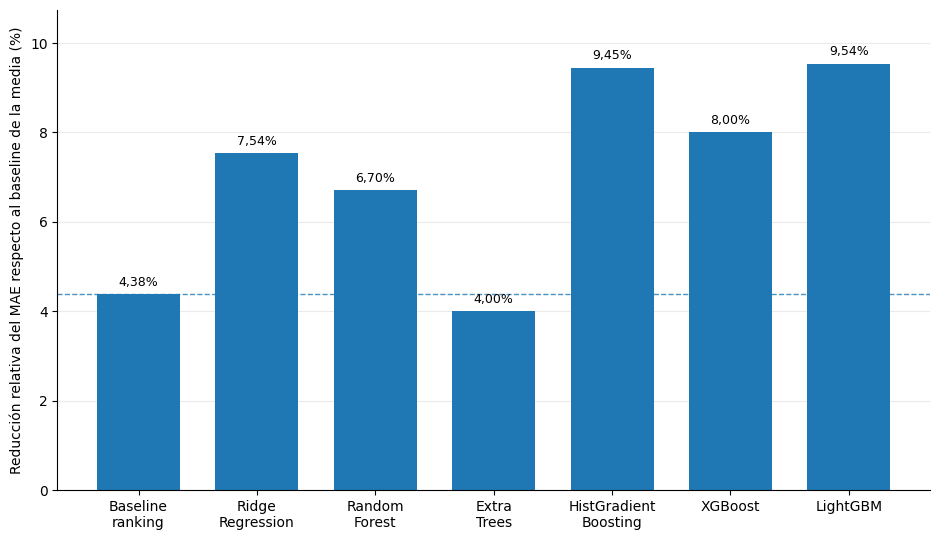

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# 1. CALCULAR DIRECTAMENTE LOS MAE DE LOS DOS BASELINES
# ============================================================

mae_baseline_media = resultados_baseline["MAE"].mean()

mae_baseline_ranking = resultados_ranking["MAE"].mean()


# ============================================================
# 2. CALCULAR DIRECTAMENTE EL RESUMEN DEL BENCHMARK
# ============================================================

benchmark_figura = (
    resultados_benchmark_base
    .groupby("modelo")
    .agg(
        MAE_medio=("MAE", "mean")
    )
)


# ============================================================
# 3. CONSTRUIR LOS DATOS QUE SE REPRESENTARÁN
# ============================================================

datos_figura = pd.DataFrame(
    {
        "Modelo": [
            "Baseline\nranking",
            "Ridge\nRegression",
            "Random\nForest",
            "Extra\nTrees",
            "HistGradient\nBoosting",
            "XGBoost",
            "LightGBM"
        ],
        "MAE_medio": [
            mae_baseline_ranking,
            benchmark_figura.loc["Ridge", "MAE_medio"],
            benchmark_figura.loc["Random Forest", "MAE_medio"],
            benchmark_figura.loc["Extra Trees", "MAE_medio"],
            benchmark_figura.loc["HistGradientBoosting", "MAE_medio"],
            benchmark_figura.loc["XGBoost", "MAE_medio"],
            benchmark_figura.loc["LightGBM", "MAE_medio"]
        ]
    }
)


# ============================================================
# 4. CALCULAR LA REDUCCIÓN RELATIVA DEL MAE
#    RESPECTO AL BASELINE BASADO EN LA MEDIA
# ============================================================

datos_figura["reduccion_relativa_mae_pct"] = (
    (
        mae_baseline_media
        - datos_figura["MAE_medio"]
    )
    / mae_baseline_media
    * 100
)


# ============================================================
# 5. NIVEL DEL BASELINE BASADO EN DIFF_RANKING
# ============================================================

reduccion_baseline_ranking = (
    (
        mae_baseline_media
        - mae_baseline_ranking
    )
    / mae_baseline_media
    * 100
)


# ============================================================
# 6. POSICIONES DE LAS BARRAS
# ============================================================

x = np.arange(
    len(datos_figura)
)


# ============================================================
# 7. FIGURA
# ============================================================

fig, ax = plt.subplots(
    figsize=(9.5, 5.5)
)


barras = ax.bar(
    x,
    datos_figura["reduccion_relativa_mae_pct"],
    width=0.70
)


# ============================================================
# 8. LÍNEA DE REFERENCIA DEL BASELINE DE RANKING
# ============================================================

ax.axhline(
    reduccion_baseline_ranking,
    linestyle="--",
    linewidth=1,
    alpha=0.8
)


# ============================================================
# 9. VALORES SOBRE LAS BARRAS
# ============================================================

for barra, valor in zip(
    barras,
    datos_figura["reduccion_relativa_mae_pct"]
):

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.12,
        f"{valor:.2f}%".replace(".", ","),
        ha="center",
        va="bottom",
        fontsize=9
    )


# ============================================================
# 10. FORMATO DE LOS EJES
# ============================================================

ax.set_xticks(x)

ax.set_xticklabels(
    datos_figura["Modelo"]
)

ax.set_ylabel(
    "Reducción relativa del MAE respecto al baseline de la media (%)"
)

ax.set_xlabel("")


# ============================================================
# 11. ACABADO VISUAL
# ============================================================

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_ylim(
    0,
    datos_figura["reduccion_relativa_mae_pct"].max() + 1.2
)

plt.tight_layout()
plt.show()

## Optimización de HistGradientBoosting

Una vez cerrado el benchmark inicial, se inicia la optimización de los algoritmos más competitivos. HistGradientBoosting se utiliza como primer modelo para establecer el procedimiento común de ajuste de hiperparámetros.

La optimización se realiza exclusivamente sobre el modelo base y utilizando las cinco particiones temporales definidas previamente. La métrica principal de selección continúa siendo el MAE medio de validación, mientras que RMSE y R² se conservan como medidas secundarias.

Se utiliza una búsqueda aleatoria sobre un espacio previamente definido de hiperparámetros. Este procedimiento permite explorar un conjunto relativamente amplio de configuraciones sin evaluar exhaustivamente todas las combinaciones posibles.

Los parámetros considerados controlan distintos componentes del modelo: la función de pérdida, la contribución de cada árbol, el número de iteraciones, la complejidad de los árboles, el número mínimo de observaciones por hoja y la regularización L2.

Se mantienen desactivados los mecanismos automáticos de *early stopping*, de forma que la selección de configuraciones dependa exclusivamente de las cinco particiones temporales establecidas para el estudio.

La búsqueda se realiza antes de incorporar las variables de carga competitiva. De esta forma, la elección de la arquitectura y de sus principales hiperparámetros no está condicionada por el resultado del experimento principal BASE frente a BASE+CARGA.

In [15]:
from sklearn.model_selection import RandomizedSearchCV


# ============================================================
# 1. PIPELINE PARA EL TUNING
# ============================================================

pipeline_hgb = Pipeline(
    steps=[
        (
            "preprocesamiento",
            clone(preprocesamiento_arboles)
        ),
        (
            "modelo",
            HistGradientBoostingRegressor(
                early_stopping=False,
                random_state=semilla_modelos
            )
        )
    ]
)


# ============================================================
# 2. ESPACIO DE HIPERPARÁMETROS
# ============================================================

espacio_hgb = {
    "modelo__loss": [
        "squared_error",
        "absolute_error"
    ],
    "modelo__learning_rate": [
        0.03,
        0.05,
        0.08,
        0.10,
        0.15
    ],
    "modelo__max_iter": [
        100,
        200,
        300,
        500
    ],
    "modelo__max_leaf_nodes": [
        7,
        15,
        31,
        63
    ],
    "modelo__min_samples_leaf": [
        20,
        50,
        100,
        200
    ],
    "modelo__l2_regularization": [
        0.0,
        0.1,
        1.0,
        5.0,
        10.0
    ]
}


# ============================================================
# 3. BÚSQUEDA TEMPORAL
# ============================================================

busqueda_hgb = RandomizedSearchCV(
    estimator=pipeline_hgb,
    param_distributions=espacio_hgb,
    n_iter=60,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    refit="MAE",
    cv=cv_temporal,
    random_state=semilla_modelos,
    n_jobs=-1,
    return_train_score=False,
    verbose=1
)


busqueda_hgb.fit(
    X_base,
    y
)


# ============================================================
# 4. RESULTADOS DE LA BÚSQUEDA
# ============================================================

resultados_tuning_hgb = pd.DataFrame(
    busqueda_hgb.cv_results_
)

resultados_tuning_hgb["MAE_medio"] = (
    -resultados_tuning_hgb["mean_test_MAE"]
)

resultados_tuning_hgb["MAE_std"] = (
    resultados_tuning_hgb["std_test_MAE"]
)

resultados_tuning_hgb["RMSE_medio"] = (
    -resultados_tuning_hgb["mean_test_RMSE"]
)

resultados_tuning_hgb["R2_medio"] = (
    resultados_tuning_hgb["mean_test_R2"]
)


columnas_mostrar = [
    "MAE_medio",
    "MAE_std",
    "RMSE_medio",
    "R2_medio",
    "param_modelo__loss",
    "param_modelo__learning_rate",
    "param_modelo__max_iter",
    "param_modelo__max_leaf_nodes",
    "param_modelo__min_samples_leaf",
    "param_modelo__l2_regularization"
]


mejores_hgb = (
    resultados_tuning_hgb[
        columnas_mostrar
    ]
    .sort_values("MAE_medio")
    .head(10)
)


display(mejores_hgb)

print(
    "\nMejores hiperparámetros:"
)

print(
    busqueda_hgb.best_params_
)

print(
    "\nMejor MAE medio:",
    -busqueda_hgb.best_score_
)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,MAE_medio,MAE_std,RMSE_medio,R2_medio,param_modelo__loss,param_modelo__learning_rate,param_modelo__max_iter,param_modelo__max_leaf_nodes,param_modelo__min_samples_leaf,param_modelo__l2_regularization
29,0.101188,0.000995,0.127883,0.132018,squared_error,0.05,100,63,50,1.0
46,0.101192,0.001002,0.127970,0.130812,squared_error,0.10,100,31,100,5.0
6,0.101231,0.000990,0.127999,0.130443,squared_error,0.05,200,31,100,10.0
28,0.101244,0.000986,0.127979,0.130726,squared_error,0.08,100,31,50,5.0
10,0.101269,0.000991,0.128039,0.129878,squared_error,0.05,300,15,200,1.0
12,0.101274,0.000859,0.127941,0.131254,squared_error,0.05,100,31,20,0.1
17,0.101282,0.001037,0.128082,0.129307,squared_error,0.05,300,31,100,0.0
34,0.101292,0.000991,0.127964,0.130904,squared_error,0.05,200,15,50,5.0
55,0.101299,0.001012,0.128108,0.128944,squared_error,0.08,200,15,200,1.0
30,0.101304,0.000977,0.128191,0.127830,squared_error,0.15,200,7,200,1.0



Mejores hiperparámetros:
{'modelo__min_samples_leaf': 50, 'modelo__max_leaf_nodes': 63, 'modelo__max_iter': 100, 'modelo__loss': 'squared_error', 'modelo__learning_rate': 0.05, 'modelo__l2_regularization': 1.0}

Mejor MAE medio: 0.10118849737952673


### Comprobación de la configuración seleccionada de HistGradientBoosting

Antes de cerrar la optimización de HistGradientBoosting se comprueba que todas las configuraciones evaluadas hayan producido métricas válidas y se analiza el comportamiento temporal de la mejor configuración.

La comparación por fold permite determinar si la reducción del MAE medio obtenida mediante el ajuste de hiperparámetros es consistente entre los diferentes periodos de validación o si se encuentra concentrada en una temporada concreta.

Esta comprobación no modifica la configuración seleccionada ni realiza nuevos entrenamientos. Utiliza directamente los resultados generados durante la búsqueda temporal.

In [16]:
# ============================================================
# 1. COMPROBACIÓN DE RESULTADOS VÁLIDOS
# ============================================================

assert np.isfinite(
    resultados_tuning_hgb["mean_test_MAE"]
).all()

assert np.isfinite(
    resultados_tuning_hgb["mean_test_RMSE"]
).all()

assert np.isfinite(
    resultados_tuning_hgb["mean_test_R2"]
).all()


# ============================================================
# 2. MAE DE LA MEJOR CONFIGURACIÓN POR FOLD
# ============================================================

indice_mejor_hgb = busqueda_hgb.best_index_

mae_hgb_optimizado = [
    -resultados_tuning_hgb.loc[
        indice_mejor_hgb,
        f"split{numero_fold}_test_MAE"
    ]
    for numero_fold in range(len(cv_temporal))
]


comparacion_hgb = (
    resultados_hgb_base[
        ["fold", "MAE"]
    ]
    .rename(
        columns={
            "MAE": "MAE_inicial"
        }
    )
    .copy()
)

comparacion_hgb["MAE_optimizado"] = (
    mae_hgb_optimizado
)

comparacion_hgb["mejora_MAE"] = (
    comparacion_hgb["MAE_inicial"]
    - comparacion_hgb["MAE_optimizado"]
)


display(comparacion_hgb)

print(
    "\nMejora media del MAE:",
    comparacion_hgb["mejora_MAE"].mean()
)

print(
    "\nResultados del tuning de HGB: VÁLIDOS"
)

,fold,MAE_inicial,MAE_optimizado,mejora_MAE
0,1,0.101976,0.101597,0.000379
1,2,0.100270,0.100080,0.000190
2,3,0.102999,0.102853,0.000146
3,4,0.101179,0.101107,0.000073
4,5,0.100413,0.100307,0.000106



Mejora media del MAE: 0.00017893449050656595

Resultados del tuning de HGB: VÁLIDOS


## Optimización de LightGBM

Tras cerrar la optimización de HistGradientBoosting, se aplica el mismo procedimiento general a LightGBM, uno de los algoritmos con mejor rendimiento en el benchmark inicial.

La búsqueda utiliza exclusivamente los predictores del modelo base y las cinco particiones temporales definidas previamente. El MAE medio continúa siendo el criterio principal de selección, manteniéndose RMSE y R² como métricas complementarias.

La optimización se centra en los hiperparámetros que regulan la función de pérdida, la velocidad de aprendizaje, el número de iteraciones, la complejidad de los árboles y la regularización.

Se comparan las funciones de pérdida L2 y L1, sin asumir previamente que la función que coincide con la métrica MAE vaya a producir necesariamente el mejor rendimiento fuera de muestra.

Al igual que en HistGradientBoosting, se mantiene un presupuesto de búsqueda limitado y previamente definido para evitar una exploración excesiva del espacio de hiperparámetros sobre las mismas particiones de validación.

In [17]:
# ============================================================
# 1. PIPELINE PARA LIGHTGBM
# ============================================================

pipeline_lightgbm = Pipeline(
    steps=[
        (
            "preprocesamiento",
            clone(preprocesamiento_arboles)
        ),
        (
            "modelo",
            LGBMRegressor(
                random_state=semilla_modelos,
                n_jobs=1,
                verbosity=-1
            )
        )
    ]
)


# ============================================================
# 2. ESPACIO DE HIPERPARÁMETROS
# ============================================================

espacio_lightgbm = {
    "modelo__objective": [
        "regression",
        "regression_l1"
    ],
    "modelo__learning_rate": [
        0.03,
        0.05,
        0.08,
        0.10,
        0.15
    ],
    "modelo__n_estimators": [
        100,
        200,
        300,
        500
    ],
    "modelo__num_leaves": [
        7,
        15,
        31,
        63
    ],
    "modelo__min_child_samples": [
        20,
        50,
        100,
        200
    ],
    "modelo__reg_alpha": [
        0.0,
        0.1,
        1.0,
        5.0
    ],
    "modelo__reg_lambda": [
        0.0,
        0.1,
        1.0,
        5.0,
        10.0
    ]
}


# ============================================================
# 3. BÚSQUEDA TEMPORAL
# ============================================================

busqueda_lightgbm = RandomizedSearchCV(
    estimator=pipeline_lightgbm,
    param_distributions=espacio_lightgbm,
    n_iter=60,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    refit="MAE",
    cv=cv_temporal,
    random_state=semilla_modelos,
    n_jobs=-1,
    return_train_score=False,
    verbose=1
)


busqueda_lightgbm.fit(
    X_base,
    y
)


# ============================================================
# 4. RESULTADOS
# ============================================================

resultados_tuning_lightgbm = pd.DataFrame(
    busqueda_lightgbm.cv_results_
)

resultados_tuning_lightgbm["MAE_medio"] = (
    -resultados_tuning_lightgbm["mean_test_MAE"]
)

resultados_tuning_lightgbm["MAE_std"] = (
    resultados_tuning_lightgbm["std_test_MAE"]
)

resultados_tuning_lightgbm["RMSE_medio"] = (
    -resultados_tuning_lightgbm["mean_test_RMSE"]
)

resultados_tuning_lightgbm["R2_medio"] = (
    resultados_tuning_lightgbm["mean_test_R2"]
)


columnas_mostrar_lightgbm = [
    "MAE_medio",
    "MAE_std",
    "RMSE_medio",
    "R2_medio",
    "param_modelo__objective",
    "param_modelo__learning_rate",
    "param_modelo__n_estimators",
    "param_modelo__num_leaves",
    "param_modelo__min_child_samples",
    "param_modelo__reg_alpha",
    "param_modelo__reg_lambda"
]


mejores_lightgbm = (
    resultados_tuning_lightgbm[
        columnas_mostrar_lightgbm
    ]
    .sort_values("MAE_medio")
    .head(10)
)


display(mejores_lightgbm)

print(
    "\nMejores hiperparámetros:"
)

print(
    busqueda_lightgbm.best_params_
)

print(
    "\nMejor MAE medio:",
    -busqueda_lightgbm.best_score_
)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,MAE_medio,MAE_std,RMSE_medio,R2_medio,param_modelo__objective,param_modelo__learning_rate,param_modelo__n_estimators,param_modelo__num_leaves,param_modelo__min_child_samples,param_modelo__reg_alpha,param_modelo__reg_lambda
15,0.101192,0.000890,0.127934,0.131307,regression,0.03,300,31,100,0.1,0.0
44,0.101223,0.000862,0.127919,0.131520,regression,0.03,200,31,100,0.1,5.0
35,0.101236,0.001036,0.128044,0.129788,regression,0.10,200,15,100,0.1,1.0
16,0.101307,0.000882,0.127875,0.132162,regression,0.03,100,63,50,0.1,10.0
42,0.101323,0.000950,0.128050,0.129732,regression,0.10,100,15,20,1.0,10.0
33,0.101325,0.000873,0.127955,0.131075,regression,0.03,100,63,200,0.1,1.0
32,0.101393,0.000992,0.128119,0.128809,regression,0.10,200,7,20,0.1,10.0
54,0.101441,0.000951,0.128194,0.127784,regression,0.15,100,7,20,1.0,5.0
59,0.101470,0.000852,0.128158,0.128295,regression,0.05,100,15,20,1.0,1.0
47,0.101501,0.000863,0.128193,0.127808,regression,0.05,100,15,100,1.0,0.0



Mejores hiperparámetros:
{'modelo__reg_lambda': 0.0, 'modelo__reg_alpha': 0.1, 'modelo__objective': 'regression', 'modelo__num_leaves': 31, 'modelo__n_estimators': 300, 'modelo__min_child_samples': 100, 'modelo__learning_rate': 0.03}

Mejor MAE medio: 0.10119204500870219


### Comprobación de la configuración seleccionada de LightGBM

Antes de decidir si la optimización de LightGBM requiere un refinamiento adicional, se analiza el comportamiento temporal de la mejor configuración obtenida.

Se compara el MAE de la configuración inicial con el de la configuración seleccionada en cada uno de los cinco periodos de validación. Esta comprobación permite determinar si la mejora media es consistente entre temporadas o si depende principalmente de un periodo concreto.

Aunque la tasa de aprendizaje seleccionada se situó en el límite inferior del espacio explorado, la mejora obtenida respecto a la configuración inicial fue de magnitud reducida y no presentó una ventaja uniforme en todos los periodos de validación. Por este motivo, se consideró suficiente la optimización realizada y se cerró el ajuste de LightGBM sin ampliar nuevamente la búsqueda sobre las mismas particiones temporales.

In [18]:
# ============================================================
# MAE DE LA MEJOR CONFIGURACIÓN POR FOLD
# ============================================================

indice_mejor_lightgbm = busqueda_lightgbm.best_index_

mae_lightgbm_optimizado = [
    -resultados_tuning_lightgbm.loc[
        indice_mejor_lightgbm,
        f"split{numero_fold}_test_MAE"
    ]
    for numero_fold in range(len(cv_temporal))
]


comparacion_lightgbm = (
    resultados_lightgbm_base[
        ["fold", "MAE"]
    ]
    .rename(
        columns={
            "MAE": "MAE_inicial"
        }
    )
    .copy()
)

comparacion_lightgbm["MAE_optimizado"] = (
    mae_lightgbm_optimizado
)

comparacion_lightgbm["mejora_MAE"] = (
    comparacion_lightgbm["MAE_inicial"]
    - comparacion_lightgbm["MAE_optimizado"]
)


display(comparacion_lightgbm)

print(
    "\nMejora media del MAE:",
    comparacion_lightgbm["mejora_MAE"].mean()
)

,fold,MAE_inicial,MAE_optimizado,mejora_MAE
0,1,0.101842,0.101615,0.000228
1,2,0.100225,0.100317,-0.000092
2,3,0.102851,0.102715,0.000136
3,4,0.101137,0.100908,0.000229
4,5,0.100273,0.100405,-0.000132



Mejora media del MAE: 7.362976752232352e-05


## Optimización de XGBoost

Tras completar la optimización de HistGradientBoosting y LightGBM, se procede al ajuste de XGBoost, tercer algoritmo de boosting seleccionado como finalista del benchmark inicial.

La optimización utiliza exclusivamente los predictores del modelo base y las mismas cinco particiones temporales empleadas en el resto del proceso. El MAE medio continúa siendo el criterio principal de selección, manteniéndose RMSE y R² como métricas complementarias.

La búsqueda se centra en los hiperparámetros que regulan la velocidad de aprendizaje, el número y complejidad de los árboles, el peso mínimo requerido en los nodos hijos, el muestreo de observaciones y predictores y la regularización L1 y L2.

También se comparan las funciones de pérdida cuadrática y absoluta, sin asumir que la coincidencia entre la función de entrenamiento y la métrica principal de evaluación produzca necesariamente el mejor rendimiento temporal.

La búsqueda mantiene un presupuesto controlado y se realiza íntegramente dentro del conjunto de desarrollo, sin utilizar información correspondiente a la temporada 2024.

In [19]:
# ============================================================
# 1. PIPELINE PARA XGBOOST
# ============================================================

pipeline_xgboost = Pipeline(
    steps=[
        (
            "preprocesamiento",
            clone(preprocesamiento_arboles)
        ),
        (
            "modelo",
            XGBRegressor(
                tree_method="hist",
                random_state=semilla_modelos,
                n_jobs=1,
                verbosity=0
            )
        )
    ]
)


# ============================================================
# 2. ESPACIO DE HIPERPARÁMETROS
# ============================================================

espacio_xgboost = {
    "modelo__objective": [
        "reg:squarederror",
        "reg:absoluteerror"
    ],
    "modelo__learning_rate": [
        0.02,
        0.03,
        0.05,
        0.08,
        0.10
    ],
    "modelo__n_estimators": [
        100,
        200,
        300,
        500
    ],
    "modelo__max_depth": [
        2,
        3,
        4,
        5,
        6
    ],
    "modelo__min_child_weight": [
        1,
        5,
        10,
        20
    ],
    "modelo__subsample": [
        0.7,
        0.85,
        1.0
    ],
    "modelo__colsample_bytree": [
        0.7,
        0.85,
        1.0
    ],
    "modelo__reg_alpha": [
        0.0,
        0.1,
        1.0
    ],
    "modelo__reg_lambda": [
        0.1,
        1.0,
        5.0,
        10.0
    ]
}


# ============================================================
# 3. BÚSQUEDA TEMPORAL
# ============================================================

busqueda_xgboost = RandomizedSearchCV(
    estimator=pipeline_xgboost,
    param_distributions=espacio_xgboost,
    n_iter=60,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    refit="MAE",
    cv=cv_temporal,
    random_state=semilla_modelos,
    n_jobs=-1,
    return_train_score=False,
    verbose=1
)


busqueda_xgboost.fit(
    X_base,
    y
)


# ============================================================
# 4. RESULTADOS
# ============================================================

resultados_tuning_xgboost = pd.DataFrame(
    busqueda_xgboost.cv_results_
)

resultados_tuning_xgboost["MAE_medio"] = (
    -resultados_tuning_xgboost["mean_test_MAE"]
)

resultados_tuning_xgboost["MAE_std"] = (
    resultados_tuning_xgboost["std_test_MAE"]
)

resultados_tuning_xgboost["RMSE_medio"] = (
    -resultados_tuning_xgboost["mean_test_RMSE"]
)

resultados_tuning_xgboost["R2_medio"] = (
    resultados_tuning_xgboost["mean_test_R2"]
)


columnas_mostrar_xgboost = [
    "MAE_medio",
    "MAE_std",
    "RMSE_medio",
    "R2_medio",
    "param_modelo__objective",
    "param_modelo__learning_rate",
    "param_modelo__n_estimators",
    "param_modelo__max_depth",
    "param_modelo__min_child_weight",
    "param_modelo__subsample",
    "param_modelo__colsample_bytree",
    "param_modelo__reg_alpha",
    "param_modelo__reg_lambda"
]


mejores_xgboost = (
    resultados_tuning_xgboost[
        columnas_mostrar_xgboost
    ]
    .sort_values("MAE_medio")
    .head(10)
)


display(mejores_xgboost)

print(
    "\nMejores hiperparámetros:"
)

print(
    busqueda_xgboost.best_params_
)

print(
    "\nMejor MAE medio:",
    -busqueda_xgboost.best_score_
)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


,MAE_medio,MAE_std,RMSE_medio,R2_medio,param_modelo__objective,param_modelo__learning_rate,param_modelo__n_estimators,param_modelo__max_depth,param_modelo__min_child_weight,param_modelo__subsample,param_modelo__colsample_bytree,param_modelo__reg_alpha,param_modelo__reg_lambda
15,0.101135,0.001018,0.127934,0.131327,reg:squarederror,0.02,300,6,10,0.70,1.00,1.0,1.0
36,0.101193,0.001113,0.127989,0.130579,reg:squarederror,0.03,300,6,20,0.70,0.70,0.1,5.0
49,0.101244,0.001032,0.128131,0.128638,reg:squarederror,0.08,300,4,1,0.70,0.85,1.0,1.0
51,0.101267,0.001049,0.128123,0.128773,reg:squarederror,0.08,100,6,10,0.85,1.00,0.1,0.1
17,0.101274,0.000901,0.127851,0.132496,reg:squarederror,0.03,100,6,1,0.85,1.00,0.0,0.1
44,0.101310,0.001049,0.128063,0.129591,reg:squarederror,0.05,200,4,5,1.00,0.85,0.1,1.0
38,0.101324,0.000951,0.128010,0.130331,reg:squarederror,0.02,300,5,5,1.00,0.70,0.0,0.1
45,0.101336,0.001155,0.128258,0.126908,reg:squarederror,0.08,500,3,5,0.85,1.00,0.1,1.0
23,0.101337,0.001203,0.128236,0.127243,reg:squarederror,0.05,500,4,5,0.85,1.00,0.0,1.0
42,0.101361,0.000970,0.128108,0.128986,reg:squarederror,0.03,300,4,10,1.00,0.70,0.0,5.0



Mejores hiperparámetros:
{'modelo__subsample': 0.7, 'modelo__reg_lambda': 1.0, 'modelo__reg_alpha': 1.0, 'modelo__objective': 'reg:squarederror', 'modelo__n_estimators': 300, 'modelo__min_child_weight': 10, 'modelo__max_depth': 6, 'modelo__learning_rate': 0.02, 'modelo__colsample_bytree': 1.0}

Mejor MAE medio: 0.10113544161343022


### Comprobación de la configuración seleccionada de XGBoost

Antes de cerrar la optimización de XGBoost se comprueba la validez de las métricas obtenidas y se analiza el comportamiento temporal de la mejor configuración seleccionada.

La comparación por fold permite determinar si la mejora observada respecto a la configuración inicial se reproduce de forma consistente entre los diferentes periodos de validación o si depende principalmente de una temporada concreta.

La configuración seleccionada mejoró el MAE respecto a la configuración inicial en los cinco periodos de validación, mostrando una ganancia temporalmente consistente. Aunque algunos hiperparámetros se situaron en los límites del espacio explorado, la mejora obtenida se consideró suficiente para cerrar la optimización sin realizar búsquedas locales adicionales sobre las mismas particiones de validación.

In [20]:
# ============================================================
# 1. COMPROBACIÓN DE RESULTADOS VÁLIDOS
# ============================================================

columnas_metricas_xgb = [
    "mean_test_MAE",
    "mean_test_RMSE",
    "mean_test_R2"
]

assert np.isfinite(
    resultados_tuning_xgboost[columnas_metricas_xgb]
).all().all()


# ============================================================
# 2. MAE DE LA MEJOR CONFIGURACIÓN POR FOLD
# ============================================================

indice_mejor_xgboost = busqueda_xgboost.best_index_

mae_xgboost_optimizado = [
    -resultados_tuning_xgboost.loc[
        indice_mejor_xgboost,
        f"split{numero_fold}_test_MAE"
    ]
    for numero_fold in range(len(cv_temporal))
]


comparacion_xgboost = (
    resultados_xgboost_base[
        ["fold", "MAE"]
    ]
    .rename(
        columns={
            "MAE": "MAE_inicial"
        }
    )
    .copy()
)

comparacion_xgboost["MAE_optimizado"] = (
    mae_xgboost_optimizado
)

comparacion_xgboost["mejora_MAE"] = (
    comparacion_xgboost["MAE_inicial"]
    - comparacion_xgboost["MAE_optimizado"]
)


display(comparacion_xgboost)

print(
    "\nMejora media del MAE:",
    comparacion_xgboost["mejora_MAE"].mean()
)

print(
    "\nResultados del tuning de XGBoost: VÁLIDOS"
)

,fold,MAE_inicial,MAE_optimizado,mejora_MAE
0,1,0.104449,0.101617,0.002832
1,2,0.101857,0.100017,0.001840
2,3,0.104375,0.102823,0.001552
3,4,0.102394,0.100996,0.001398
4,5,0.101850,0.100224,0.001626



Mejora media del MAE: 0.0018495681324295881

Resultados del tuning de XGBoost: VÁLIDOS


## Optimización de Ridge Regression

Como referencia lineal del estudio se optimiza también Ridge Regression. A diferencia de los modelos basados en boosting, Ridge presenta un espacio de ajuste mucho más reducido, por lo que la optimización se limita al parámetro `alpha`, que controla la intensidad de la regularización L2.

La búsqueda se realiza sobre una escala logarítmica para representar tanto niveles muy bajos como niveles elevados de regularización. Todas las configuraciones utilizan el mismo pipeline de imputación y estandarización y se evalúan mediante las cinco particiones temporales definidas previamente.

El MAE medio continúa siendo el criterio principal de selección, mientras que RMSE y R² se mantienen como métricas complementarias. El objetivo no es convertir Ridge en el modelo final necesariamente, sino disponer de una referencia lineal optimizada y comparable en condiciones justas con los modelos no lineales.

In [21]:
from sklearn.model_selection import GridSearchCV


# ============================================================
# 1. PIPELINE DE RIDGE
# ============================================================

pipeline_ridge = Pipeline(
    steps=[
        (
            "preprocesamiento",
            clone(preprocesamiento_escalado)
        ),
        (
            "modelo",
            Ridge()
        )
    ]
)


# ============================================================
# 2. ESPACIO DE REGULARIZACIÓN
# ============================================================

espacio_ridge = {
    "modelo__alpha": np.logspace(
        -4,
        4,
        17
    )
}


# ============================================================
# 3. BÚSQUEDA TEMPORAL
# ============================================================

busqueda_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=espacio_ridge,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    refit="MAE",
    cv=cv_temporal,
    n_jobs=-1,
    return_train_score=False
)


busqueda_ridge.fit(
    X_base,
    y
)


# ============================================================
# 4. RESULTADOS
# ============================================================

resultados_tuning_ridge = pd.DataFrame(
    busqueda_ridge.cv_results_
)

resultados_tuning_ridge["MAE_medio"] = (
    -resultados_tuning_ridge["mean_test_MAE"]
)

resultados_tuning_ridge["MAE_std"] = (
    resultados_tuning_ridge["std_test_MAE"]
)

resultados_tuning_ridge["RMSE_medio"] = (
    -resultados_tuning_ridge["mean_test_RMSE"]
)

resultados_tuning_ridge["R2_medio"] = (
    resultados_tuning_ridge["mean_test_R2"]
)


mejores_ridge = (
    resultados_tuning_ridge[
        [
            "MAE_medio",
            "MAE_std",
            "RMSE_medio",
            "R2_medio",
            "param_modelo__alpha"
        ]
    ]
    .sort_values("MAE_medio")
    .head(10)
)


display(mejores_ridge)

print(
    "\nMejor alpha:",
    busqueda_ridge.best_params_["modelo__alpha"]
)

print(
    "\nMejor MAE medio:",
    -busqueda_ridge.best_score_
)

,MAE_medio,MAE_std,RMSE_medio,R2_medio,param_modelo__alpha
0,0.103508,0.000912,0.129999,0.103044,0.000100
1,0.103508,0.000912,0.129999,0.103044,0.000316
2,0.103508,0.000912,0.129999,0.103044,0.001000
3,0.103508,0.000912,0.129999,0.103044,0.003162
4,0.103508,0.000912,0.129999,0.103044,0.010000
5,0.103508,0.000912,0.129999,0.103044,0.031623
6,0.103508,0.000912,0.129999,0.103044,0.100000
7,0.103508,0.000912,0.129999,0.103043,0.316228
8,0.103508,0.000912,0.129999,0.103043,1.000000
9,0.103508,0.000912,0.129999,0.103040,3.162278



Mejor alpha: 0.0001

Mejor MAE medio: 0.10350785208521558


## Comparación de los modelos optimizados

Una vez completada la optimización de los principales modelos candidatos, se realiza una comparación conjunta de su comportamiento en las cinco particiones temporales.

El MAE medio continúa siendo el criterio principal de selección, pero diferencias muy reducidas entre algoritmos no se interpretan automáticamente como una superioridad sustantiva. Por ello, se examina también el rendimiento individual en cada periodo de validación y su estabilidad temporal.

Esta comparación permite seleccionar la arquitectura que se utilizará posteriormente en el experimento principal entre el modelo base y el modelo que incorpora las variables de carga competitiva.

La selección se realiza exclusivamente con los datos de desarrollo. La temporada 2024 continúa sin intervenir en ninguna decisión del proceso.

In [22]:
# ============================================================
# 1. MAE POR FOLD DE LOS MODELOS OPTIMIZADOS
# ============================================================

def extraer_mae_mejor_configuracion(
    busqueda,
    resultados
):
    indice_mejor = busqueda.best_index_

    return [
        -resultados.loc[
            indice_mejor,
            f"split{numero_fold}_test_MAE"
        ]
        for numero_fold in range(len(cv_temporal))
    ]


mae_hgb_final = extraer_mae_mejor_configuracion(
    busqueda_hgb,
    resultados_tuning_hgb
)

mae_lightgbm_final = extraer_mae_mejor_configuracion(
    busqueda_lightgbm,
    resultados_tuning_lightgbm
)

mae_xgboost_final = extraer_mae_mejor_configuracion(
    busqueda_xgboost,
    resultados_tuning_xgboost
)

mae_ridge_final = extraer_mae_mejor_configuracion(
    busqueda_ridge,
    resultados_tuning_ridge
)


# ============================================================
# 2. TABLA COMPARATIVA
# ============================================================

comparacion_modelos_optimizados = pd.DataFrame(
    {
        "fold": range(1, len(cv_temporal) + 1),
        "Ridge": mae_ridge_final,
        "HistGradientBoosting": mae_hgb_final,
        "LightGBM": mae_lightgbm_final,
        "XGBoost": mae_xgboost_final
    }
)


display(comparacion_modelos_optimizados)


# ============================================================
# 3. RESUMEN
# ============================================================

resumen_modelos_optimizados = (
    comparacion_modelos_optimizados
    .drop(columns="fold")
    .agg(["mean", "std"])
    .T
    .rename(
        columns={
            "mean": "MAE_medio",
            "std": "MAE_std"
        }
    )
    .sort_values("MAE_medio")
)


display(resumen_modelos_optimizados)

,fold,Ridge,HistGradientBoosting,LightGBM,XGBoost
0,1,0.104472,0.101597,0.101615,0.101617
1,2,0.103673,0.100080,0.100317,0.100017
2,3,0.104488,0.102853,0.102715,0.102823
3,4,0.102537,0.101107,0.100908,0.100996
4,5,0.102369,0.100307,0.100405,0.100224


,MAE_medio,MAE_std
XGBoost,0.101135,0.001138
HistGradientBoosting,0.101188,0.001112
LightGBM,0.101192,0.000995
Ridge,0.103508,0.001020


## Experimento principal: aportación de las variables de carga competitiva

Una vez seleccionada la arquitectura principal mediante el conjunto de predictores tradicionales, se evalúa la aportación incremental de las variables de carga competitiva.

XGBoost se utiliza como arquitectura principal al haber obtenido el menor MAE medio durante la validación temporal interna, aunque su rendimiento fue muy próximo al de HistGradientBoosting y LightGBM.

Para aislar el efecto de las variables de carga, se mantienen congelados los hiperparámetros seleccionados previamente. Se comparan dos especificaciones utilizando exactamente las mismas observaciones y las mismas cinco particiones temporales:

- **Modelo base:** predictores tradicionales y variable de control temporal.
- **Modelo base + carga:** modelo base más las cinco variables diferenciales de carga seleccionadas previamente.

De este modo, la única diferencia entre ambas especificaciones es la incorporación de información de carga competitiva, evitando que una nueva optimización de hiperparámetros pueda confundirse con el efecto propio de las nuevas variables.

El MAE medio continúa siendo el criterio principal. RMSE y R² se utilizan como medidas complementarias y también se examina la diferencia de rendimiento en cada periodo temporal.

La variable `diff_torneos_365d` no se incorpora todavía, ya que se mantiene como variable de sensibilidad conforme a la selección realizada previamente.

In [23]:
# ============================================================
# 1. MODELO XGBOOST SELECCIONADO
# ============================================================

modelo_xgboost_seleccionado = clone(
    busqueda_xgboost
    .best_estimator_
    .named_steps["modelo"]
)


# ============================================================
# 2. MODELO BASE
# ============================================================

resultados_xgb_base_final, predicciones_xgb_base_final = (
    evaluar_modelo_temporal(
        nombre_modelo="XGBoost BASE",
        modelo=modelo_xgboost_seleccionado,
        X=X_base,
        y=y,
        preprocesamiento=preprocesamiento_arboles,
        cv=cv_temporal
    )
)


# ============================================================
# 3. MODELO BASE + CARGA
# ============================================================

resultados_xgb_carga, predicciones_xgb_carga = (
    evaluar_modelo_temporal(
        nombre_modelo="XGBoost BASE + CARGA",
        modelo=modelo_xgboost_seleccionado,
        X=X_principal_365d,
        y=y,
        preprocesamiento=preprocesamiento_arboles,
        cv=cv_temporal
    )
)


# ============================================================
# 4. COMPARACIÓN POR FOLD
# ============================================================

comparacion_base_carga = (
    resultados_xgb_base_final[
        ["fold", "MAE", "RMSE", "R2"]
    ]
    .rename(
        columns={
            "MAE": "MAE_base",
            "RMSE": "RMSE_base",
            "R2": "R2_base"
        }
    )
    .merge(
        resultados_xgb_carga[
            ["fold", "MAE", "RMSE", "R2"]
        ].rename(
            columns={
                "MAE": "MAE_carga",
                "RMSE": "RMSE_carga",
                "R2": "R2_carga"
            }
        ),
        on="fold"
    )
)


comparacion_base_carga["mejora_MAE"] = (
    comparacion_base_carga["MAE_base"]
    - comparacion_base_carga["MAE_carga"]
)

comparacion_base_carga["mejora_RMSE"] = (
    comparacion_base_carga["RMSE_base"]
    - comparacion_base_carga["RMSE_carga"]
)

comparacion_base_carga["mejora_R2"] = (
    comparacion_base_carga["R2_carga"]
    - comparacion_base_carga["R2_base"]
)


display(comparacion_base_carga)


# ============================================================
# 5. RESUMEN GLOBAL
# ============================================================

resumen_base_carga = pd.DataFrame(
    {
        "especificacion": [
            "BASE",
            "BASE + CARGA"
        ],
        "MAE_medio": [
            resultados_xgb_base_final["MAE"].mean(),
            resultados_xgb_carga["MAE"].mean()
        ],
        "MAE_std": [
            resultados_xgb_base_final["MAE"].std(),
            resultados_xgb_carga["MAE"].std()
        ],
        "RMSE_medio": [
            resultados_xgb_base_final["RMSE"].mean(),
            resultados_xgb_carga["RMSE"].mean()
        ],
        "R2_medio": [
            resultados_xgb_base_final["R2"].mean(),
            resultados_xgb_carga["R2"].mean()
        ]
    }
)


display(resumen_base_carga)

print(
    "\nMejora media del MAE al incorporar carga:",
    comparacion_base_carga["mejora_MAE"].mean()
)

,fold,MAE_base,RMSE_base,R2_base,MAE_carga,RMSE_carga,R2_carga,mejora_MAE,mejora_RMSE,mejora_R2
0,1,0.101617,0.129149,0.155969,0.101363,0.128920,0.158961,0.000254,0.000229,0.002992
1,2,0.100017,0.127150,0.126454,0.099612,0.126807,0.131150,0.000405,0.000342,0.004696
2,3,0.102823,0.128947,0.099116,0.101233,0.127311,0.121833,0.001590,0.001636,0.022718
3,4,0.100996,0.127493,0.138836,0.100258,0.126514,0.152011,0.000738,0.000979,0.013175
4,5,0.100224,0.126932,0.136261,0.099229,0.126091,0.147669,0.000994,0.000841,0.011408


,especificacion,MAE_medio,MAE_std,RMSE_medio,R2_medio
0,BASE,0.101135,0.001138,0.127934,0.131327
1,BASE + CARGA,0.100339,0.000951,0.127129,0.142325



Mejora media del MAE al incorporar carga: 0.0007962980676253006


### Incertidumbre de la mejora aportada por las variables de carga

La comparación temporal muestra una reducción del MAE al incorporar las variables de carga en los cinco periodos de validación. Dado que la magnitud de esta mejora es reducida, se complementa el análisis puntual con una estimación de su incertidumbre mediante bootstrap.

Las dos observaciones correspondientes a un mismo partido no se consideran unidades independientes. Por ello, los errores de las dos perspectivas jugador–partido se agregan previamente mediante el identificador del encuentro y el remuestreo se realiza posteriormente a nivel de partido.

El procedimiento se aplica de forma estratificada por fold temporal. En cada réplica bootstrap se remuestrean con reemplazo los partidos pertenecientes a cada periodo de validación, se calcula la mejora del MAE dentro de cada fold y finalmente se obtiene la media de las cinco mejoras.

El objetivo de este análisis es cuantificar la estabilidad de la diferencia observada entre el modelo base y el modelo con carga. No se modifica ningún modelo ni se utilizan datos correspondientes a 2024.

El intervalo bootstrap debe interpretarse de forma descriptiva y condicionada al procedimiento de modelización ya fijado. El remuestreo representa la variabilidad de la diferencia de error sobre los partidos de validación, manteniendo emparejadas las dos observaciones correspondientes a cada encuentro, pero no reproduce la incertidumbre asociada al proceso completo de selección de variables, elección del algoritmo y ajuste de hiperparámetros. Por tanto, su función es evaluar la estabilidad de la mejora observada y no proporcionar una inferencia completa sobre todo el procedimiento de modelado.

In [24]:
# ============================================================
# 1. UNIR LAS PREDICCIONES BASE Y CARGA
# ============================================================

errores_base_carga = (
    predicciones_xgb_base_final[
        ["indice", "fold", "y_real", "y_pred"]
    ]
    .rename(
        columns={
            "y_pred": "pred_base"
        }
    )
    .merge(
        predicciones_xgb_carga[
            ["indice", "fold", "y_pred"]
        ].rename(
            columns={
                "y_pred": "pred_carga"
            }
        ),
        on=["indice", "fold"],
        validate="one_to_one"
    )
)


# ============================================================
# 2. INCORPORAR IDENTIFICADOR DE PARTIDO
# ============================================================

errores_base_carga["_id_partido"] = (
    df_desarrollo.loc[
        errores_base_carga["indice"],
        "_id_partido"
    ].to_numpy()
)


errores_base_carga["error_base"] = (
    errores_base_carga["y_real"]
    - errores_base_carga["pred_base"]
).abs()

errores_base_carga["error_carga"] = (
    errores_base_carga["y_real"]
    - errores_base_carga["pred_carga"]
).abs()


# ============================================================
# 3. AGREGAR LAS DOS PERSPECTIVAS DE CADA PARTIDO
# ============================================================

errores_partido = (
    errores_base_carga
    .groupby(
        ["fold", "_id_partido"],
        as_index=False
    )
    .agg(
        error_base=("error_base", "mean"),
        error_carga=("error_carga", "mean")
    )
)

errores_partido["mejora_MAE"] = (
    errores_partido["error_base"]
    - errores_partido["error_carga"]
)


# ============================================================
# 4. BOOTSTRAP ESTRATIFICADO POR FOLD
# ============================================================

rng = np.random.default_rng(semilla_modelos)

numero_replicas = 5000
mejoras_bootstrap = []

datos_por_fold = {
    fold: datos["mejora_MAE"].to_numpy()
    for fold, datos in errores_partido.groupby("fold")
}


for _ in range(numero_replicas):

    mejoras_fold = []

    for valores in datos_por_fold.values():

        muestra = rng.choice(
            valores,
            size=len(valores),
            replace=True
        )

        mejoras_fold.append(
            muestra.mean()
        )

    mejoras_bootstrap.append(
        np.mean(mejoras_fold)
    )


mejoras_bootstrap = np.asarray(
    mejoras_bootstrap
)


# ============================================================
# 5. INTERVALO BOOTSTRAP
# ============================================================

limite_inferior, limite_superior = np.percentile(
    mejoras_bootstrap,
    [2.5, 97.5]
)

print(
    "Mejora media observada:",
    comparacion_base_carga["mejora_MAE"].mean()
)

print(
    "IC bootstrap 95%:",
    (limite_inferior, limite_superior)
)

print(
    "Proporción de réplicas con mejora > 0:",
    (mejoras_bootstrap > 0).mean()
)

Mejora media observada: 0.0007962980676253006
IC bootstrap 95%: (np.float64(0.0004484610910195213), np.float64(0.0011350932133349977))
Proporción de réplicas con mejora > 0: 1.0


### Interpretación del bootstrap interno

El intervalo bootstrap de la mejora permanece completamente por encima de cero y la reducción del error se reproduce en todas las réplicas generadas. Esto respalda la estabilidad descriptiva de la mejora observada durante la validación temporal interna.

Esta comprobación está condicionada a las decisiones de modelización ya adoptadas y utiliza exclusivamente los folds de desarrollo. No debe confundirse con el bootstrap de la evaluación temporal externa de 2024, que se realizará posteriormente sobre la muestra temporal externa reservada de 2024.

## Robustez de la aportación de la carga entre algoritmos

La comparación principal entre el modelo base y el modelo con variables de carga mostró una reducción del error mediante XGBoost. Para comprobar que esta mejora no depende exclusivamente de una arquitectura concreta, se replica el experimento utilizando HistGradientBoosting y LightGBM, los otros dos algoritmos que mostraron un rendimiento competitivo durante la validación interna.

En ambos casos se mantienen congelados los hiperparámetros seleccionados previamente utilizando exclusivamente el modelo base. No se realiza una nueva optimización tras incorporar las variables de carga.

Cada algoritmo se evalúa sobre exactamente las mismas observaciones y las mismas cinco particiones temporales, de modo que la única diferencia entre las dos especificaciones sea la presencia de las cinco variables de carga competitiva.

El objetivo de esta comprobación no es seleccionar nuevamente el mejor algoritmo, sino determinar si la aportación predictiva de la carga presenta consistencia entre distintas implementaciones de gradient boosting.

In [25]:
# ============================================================
# 1. MODELOS OPTIMIZADOS YA SELECCIONADOS
# ============================================================

modelo_hgb_seleccionado = clone(
    busqueda_hgb
    .best_estimator_
    .named_steps["modelo"]
)

modelo_lightgbm_seleccionado = clone(
    busqueda_lightgbm
    .best_estimator_
    .named_steps["modelo"]
)


# ============================================================
# 2. HISTGRADIENTBOOSTING: BASE Y BASE + CARGA
# ============================================================

resultados_hgb_base_final, _ = evaluar_modelo_temporal(
    nombre_modelo="HGB BASE",
    modelo=modelo_hgb_seleccionado,
    X=X_base,
    y=y,
    preprocesamiento=preprocesamiento_arboles,
    cv=cv_temporal
)

resultados_hgb_carga, _ = evaluar_modelo_temporal(
    nombre_modelo="HGB BASE + CARGA",
    modelo=modelo_hgb_seleccionado,
    X=X_principal_365d,
    y=y,
    preprocesamiento=preprocesamiento_arboles,
    cv=cv_temporal
)


# ============================================================
# 3. LIGHTGBM: BASE Y BASE + CARGA
# ============================================================

resultados_lightgbm_base_final, _ = evaluar_modelo_temporal(
    nombre_modelo="LightGBM BASE",
    modelo=modelo_lightgbm_seleccionado,
    X=X_base,
    y=y,
    preprocesamiento=preprocesamiento_arboles,
    cv=cv_temporal
)

resultados_lightgbm_carga, _ = evaluar_modelo_temporal(
    nombre_modelo="LightGBM BASE + CARGA",
    modelo=modelo_lightgbm_seleccionado,
    X=X_principal_365d,
    y=y,
    preprocesamiento=preprocesamiento_arboles,
    cv=cv_temporal
)


# ============================================================
# 4. FUNCIÓN DE COMPARACIÓN
# ============================================================

def comparar_base_carga(
    resultados_base,
    resultados_carga,
    algoritmo
):
    comparacion = (
        resultados_base[
            ["fold", "MAE"]
        ]
        .rename(
            columns={
                "MAE": "MAE_base"
            }
        )
        .merge(
            resultados_carga[
                ["fold", "MAE"]
            ].rename(
                columns={
                    "MAE": "MAE_carga"
                }
            ),
            on="fold"
        )
    )

    comparacion["algoritmo"] = algoritmo

    comparacion["mejora_MAE"] = (
        comparacion["MAE_base"]
        - comparacion["MAE_carga"]
    )

    return comparacion


comparacion_hgb_carga = comparar_base_carga(
    resultados_hgb_base_final,
    resultados_hgb_carga,
    "HistGradientBoosting"
)

comparacion_lightgbm_carga = comparar_base_carga(
    resultados_lightgbm_base_final,
    resultados_lightgbm_carga,
    "LightGBM"
)


# ============================================================
# 5. RESULTADO POR FOLD
# ============================================================

comparacion_robustez_algoritmos = pd.concat(
    [
        comparacion_hgb_carga,
        comparacion_lightgbm_carga
    ],
    ignore_index=True
)

display(
    comparacion_robustez_algoritmos[
        [
            "algoritmo",
            "fold",
            "MAE_base",
            "MAE_carga",
            "mejora_MAE"
        ]
    ]
)


# ============================================================
# 6. RESUMEN
# ============================================================

resumen_robustez_algoritmos = (
    comparacion_robustez_algoritmos
    .groupby("algoritmo")
    .agg(
        MAE_base=("MAE_base", "mean"),
        MAE_carga=("MAE_carga", "mean"),
        mejora_MAE_media=("mejora_MAE", "mean"),
        folds_con_mejora=(
            "mejora_MAE",
            lambda x: (x > 0).sum()
        )
    )
)

display(resumen_robustez_algoritmos)

,algoritmo,fold,MAE_base,MAE_carga,mejora_MAE
0,HistGradientBoosting,1,0.101597,0.101535,0.000062
1,HistGradientBoosting,2,0.100080,0.099689,0.000391
2,HistGradientBoosting,3,0.102853,0.101206,0.001646
3,HistGradientBoosting,4,0.101107,0.100381,0.000725
4,HistGradientBoosting,5,0.100307,0.099315,0.000992
5,LightGBM,1,0.101615,0.101422,0.000193
6,LightGBM,2,0.100317,0.099676,0.000641
7,LightGBM,3,0.102715,0.101250,0.001466
8,LightGBM,4,0.100908,0.100237,0.000671
9,LightGBM,5,0.100405,0.099315,0.001090


,MAE_base,MAE_carga,mejora_MAE_media,folds_con_mejora
algoritmo,,,,
HistGradientBoosting,0.101188,0.100425,0.000763,5
LightGBM,0.101192,0.100380,0.000812,5


### Interpretación de la robustez frente al algoritmo

La mejora asociada a las cinco variables principales de carga se reproduce con los otros dos algoritmos de boosting considerados. HistGradientBoosting reduce el MAE medio de 0,101188 a 0,100425 y LightGBM de 0,101192 a 0,100380.

En ambos algoritmos la reducción del MAE se observa en las cinco particiones temporales. Por tanto, la aportación predictiva del núcleo principal de variables de carga no constituye un patrón exclusivo de XGBoost, aunque la magnitud de la mejora continúa siendo reducida.

### Coherencia recíproca de las predicciones

Cada encuentro está representado mediante dos observaciones recíprocas, una desde la perspectiva de cada jugador. La variable objetivo cumple exactamente que los porcentajes de juegos ganados de ambas perspectivas suman uno.

Los modelos de regresión utilizados no imponen explícitamente esta restricción sobre sus predicciones. Por ello, como comprobación diagnóstica adicional antes de continuar con los análisis de sensibilidad y simplificación de la especificación de carga, se evalúa hasta qué punto las predicciones del modelo base y del modelo con carga respetan la estructura recíproca del problema.

Para cada partido se calcula la suma de las dos predicciones y su desviación absoluta respecto a uno. Se resumen posteriormente la desviación media, mediana, percentil 95 y máxima.

Esta comprobación es exclusivamente diagnóstica. En esta etapa no se corrigen ni transforman las predicciones.

In [26]:
# ============================================================
# 1. FUNCIÓN PARA COMPROBAR RECIPROCIDAD
# ============================================================

def evaluar_reciprocidad_predicciones(
    predicciones,
    nombre_modelo
):
    datos = predicciones[
        ["indice", "fold", "y_real", "y_pred"]
    ].copy()

    datos["_id_partido"] = (
        df_desarrollo.loc[
            datos["indice"],
            "_id_partido"
        ].to_numpy()
    )

    resumen_partido = (
        datos
        .groupby(
            ["fold", "_id_partido"],
            as_index=False
        )
        .agg(
            numero_observaciones=("y_pred", "size"),
            suma_real=("y_real", "sum"),
            suma_predicha=("y_pred", "sum")
        )
    )

    # Cada partido debe conservar sus dos perspectivas.
    assert resumen_partido[
        "numero_observaciones"
    ].eq(2).all()

    # La variable objetivo debe mantener su reciprocidad exacta.
    assert np.allclose(
        resumen_partido["suma_real"],
        1.0
    )

    resumen_partido["desviacion_reciprocidad"] = (
        resumen_partido["suma_predicha"] - 1
    ).abs()

    resumen = pd.DataFrame(
        {
            "modelo": [nombre_modelo],
            "desviacion_media": [
                resumen_partido[
                    "desviacion_reciprocidad"
                ].mean()
            ],
            "desviacion_mediana": [
                resumen_partido[
                    "desviacion_reciprocidad"
                ].median()
            ],
            "percentil_95": [
                resumen_partido[
                    "desviacion_reciprocidad"
                ].quantile(0.95)
            ],
            "desviacion_maxima": [
                resumen_partido[
                    "desviacion_reciprocidad"
                ].max()
            ]
        }
    )

    return resumen, resumen_partido


# ============================================================
# 2. MODELO BASE
# ============================================================

resumen_reciprocidad_base, reciprocidad_base = (
    evaluar_reciprocidad_predicciones(
        predicciones_xgb_base_final,
        "XGBoost BASE"
    )
)


# ============================================================
# 3. MODELO BASE + CARGA
# ============================================================

resumen_reciprocidad_carga, reciprocidad_carga = (
    evaluar_reciprocidad_predicciones(
        predicciones_xgb_carga,
        "XGBoost BASE + CARGA"
    )
)


# ============================================================
# 4. COMPARACIÓN
# ============================================================

resumen_reciprocidad = pd.concat(
    [
        resumen_reciprocidad_base,
        resumen_reciprocidad_carga
    ],
    ignore_index=True
)

display(resumen_reciprocidad)

,modelo,desviacion_media,desviacion_mediana,percentil_95,desviacion_maxima
0,XGBoost BASE,0.002867,0.002258,0.007521,0.025821
1,XGBoost BASE + CARGA,0.003499,0.002842,0.009110,0.028648


## Análisis de sensibilidad de `diff_torneos_365d`

La especificación principal de carga de 365 días se definió mediante cinco variables diferenciales representativas de distintas dimensiones de la actividad competitiva. La variable `diff_torneos_365d` se mantuvo fuera de este núcleo debido a su dependencia con `diff_juegos_365d` y se reservó previamente para una especificación ampliada de sensibilidad.

En esta etapa se compara el modelo principal de carga con el modelo ampliado que incorpora adicionalmente `diff_torneos_365d`.

La comparación mantiene el mismo algoritmo XGBoost, los hiperparámetros seleccionados previamente, las mismas observaciones, las mismas particiones temporales y el mismo procedimiento de preprocesamiento. De este modo, la única diferencia entre ambas especificaciones es la incorporación de la variable adicional.

El objetivo es determinar si la frecuencia de participación medida mediante el número diferencial de torneos aporta información predictiva incremental una vez consideradas las restantes variables de carga. La decisión se valorará atendiendo principalmente al MAE y a la consistencia de la diferencia entre los cinco periodos de validación.

In [27]:
# ============================================================
# 1. MODELO AMPLIADO DE 365 DÍAS
# ============================================================

resultados_xgb_ampliado, predicciones_xgb_ampliado = (
    evaluar_modelo_temporal(
        nombre_modelo="XGBoost CARGA + TORNEOS",
        modelo=modelo_xgboost_seleccionado,
        X=X_ampliado_365d,
        y=y,
        preprocesamiento=preprocesamiento_arboles,
        cv=cv_temporal
    )
)


# ============================================================
# 2. COMPARACIÓN CON EL MODELO PRINCIPAL DE CARGA
# ============================================================

comparacion_torneos = (
    resultados_xgb_carga[
        ["fold", "MAE", "RMSE", "R2"]
    ]
    .rename(
        columns={
            "MAE": "MAE_principal",
            "RMSE": "RMSE_principal",
            "R2": "R2_principal"
        }
    )
    .merge(
        resultados_xgb_ampliado[
            ["fold", "MAE", "RMSE", "R2"]
        ].rename(
            columns={
                "MAE": "MAE_ampliado",
                "RMSE": "RMSE_ampliado",
                "R2": "R2_ampliado"
            }
        ),
        on="fold"
    )
)


comparacion_torneos["mejora_MAE"] = (
    comparacion_torneos["MAE_principal"]
    - comparacion_torneos["MAE_ampliado"]
)

comparacion_torneos["mejora_RMSE"] = (
    comparacion_torneos["RMSE_principal"]
    - comparacion_torneos["RMSE_ampliado"]
)

comparacion_torneos["mejora_R2"] = (
    comparacion_torneos["R2_ampliado"]
    - comparacion_torneos["R2_principal"]
)


display(comparacion_torneos)


# ============================================================
# 3. RESUMEN
# ============================================================

print(
    "Mejora media del MAE:",
    comparacion_torneos["mejora_MAE"].mean()
)

print(
    "Folds con mejora:",
    (comparacion_torneos["mejora_MAE"] > 0).sum(),
    "de",
    len(comparacion_torneos)
)

,fold,MAE_principal,RMSE_principal,R2_principal,MAE_ampliado,RMSE_ampliado,R2_ampliado,mejora_MAE,mejora_RMSE,mejora_R2
0,1,0.101363,0.128920,0.158961,0.100637,0.128285,0.167225,0.000726,0.000635,0.008264
1,2,0.099612,0.126807,0.131150,0.098874,0.125529,0.148582,0.000738,0.001279,0.017432
2,3,0.101233,0.127311,0.121833,0.100371,0.126230,0.136684,0.000863,0.001081,0.014851
3,4,0.100258,0.126514,0.152011,0.100003,0.126097,0.157595,0.000256,0.000417,0.005584
4,5,0.099229,0.126091,0.147669,0.098973,0.125767,0.152041,0.000256,0.000324,0.004372


Mejora media del MAE: 0.0005676828177131887
Folds con mejora: 5 de 5


### Estabilidad temporal de la aportación incremental de la carga

Para evaluar si la mejora predictiva se mantiene a lo largo de los distintos
periodos de validación, se representa en cada fold la reducción relativa del MAE
de las especificaciones Principal y Ampliada respecto al correspondiente modelo Base.

La reducción relativa se calcula como:

\[
\text{Reducción relativa del MAE} =
\frac{\text{MAE}_{\text{Base}}-\text{MAE}_{\text{especificación}}}
{\text{MAE}_{\text{Base}}}\times 100.
\]

Los valores positivos indican una reducción del error respecto al modelo Base.
La representación por temporadas permite comprobar si la mejora mantiene una
dirección consistente entre los cinco periodos de validación temporal.

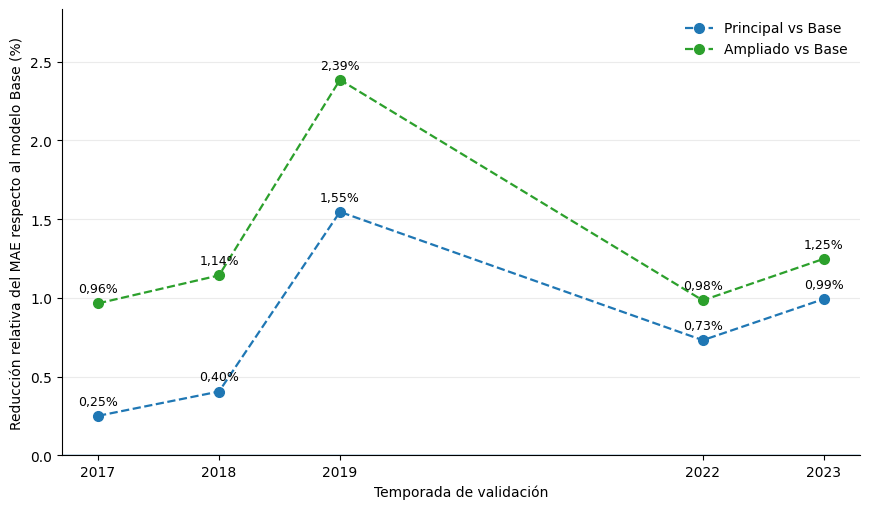

In [28]:
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# 1. UNIR LOS RESULTADOS DE LAS TRES ESPECIFICACIONES
# ============================================================

datos_estabilidad = (
    resultados_xgb_base_final[
        ["fold", "MAE"]
    ]
    .rename(
        columns={
            "MAE": "MAE_base"
        }
    )
    .merge(
        resultados_xgb_carga[
            ["fold", "MAE"]
        ].rename(
            columns={
                "MAE": "MAE_principal"
            }
        ),
        on="fold",
        validate="one_to_one"
    )
    .merge(
        resultados_xgb_ampliado[
            ["fold", "MAE"]
        ].rename(
            columns={
                "MAE": "MAE_ampliado"
            }
        ),
        on="fold",
        validate="one_to_one"
    )
)


# ============================================================
# 2. ASOCIAR CADA FOLD CON SU TEMPORADA DE VALIDACIÓN
# ============================================================

mapa_validacion = {
    fold["fold"]: fold["anio_validacion"]
    for fold in folds_definitivos
}

datos_estabilidad["temporada_validacion"] = (
    datos_estabilidad["fold"]
    .map(mapa_validacion)
)


# ============================================================
# 3. REDUCCIÓN RELATIVA DEL MAE RESPECTO AL MODELO BASE
# ============================================================

datos_estabilidad["reduccion_principal_pct"] = (
    (
        datos_estabilidad["MAE_base"]
        - datos_estabilidad["MAE_principal"]
    )
    / datos_estabilidad["MAE_base"]
    * 100
)

datos_estabilidad["reduccion_ampliado_pct"] = (
    (
        datos_estabilidad["MAE_base"]
        - datos_estabilidad["MAE_ampliado"]
    )
    / datos_estabilidad["MAE_base"]
    * 100
)


# ============================================================
# 4. ORDEN TEMPORAL
# ============================================================

datos_estabilidad = (
    datos_estabilidad
    .sort_values("temporada_validacion")
    .reset_index(drop=True)
)

anios = datos_estabilidad[
    "temporada_validacion"
].to_numpy()

principal = datos_estabilidad[
    "reduccion_principal_pct"
].to_numpy()

ampliado = datos_estabilidad[
    "reduccion_ampliado_pct"
].to_numpy()


# ============================================================
# 5. FIGURA
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.8, 5.2)
)


ax.plot(
    anios,
    principal,
    marker="o",
    markersize=7,
    linewidth=1.6,
    linestyle="--",
    color="tab:blue",
    label="Principal vs Base"
)

ax.plot(
    anios,
    ampliado,
    marker="o",
    markersize=7,
    linewidth=1.6,
    linestyle="--",
    color="tab:green",
    label="Ampliado vs Base"
)


# ============================================================
# 6. LÍNEA DE REFERENCIA
# ============================================================

ax.axhline(
    0,
    linewidth=1
)


# ============================================================
# 7. VALORES JUNTO A LOS PUNTOS
# ============================================================

for anio, valor in zip(
    anios,
    principal
):
    ax.annotate(
        f"{valor:.2f}%".replace(".", ","),
        (anio, valor),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )


for anio, valor in zip(
    anios,
    ampliado
):
    ax.annotate(
        f"{valor:.2f}%".replace(".", ","),
        (anio, valor),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )


# ============================================================
# 8. EJES
# ============================================================

ax.set_xticks(
    anios
)

ax.set_xlabel(
    "Temporada de validación"
)

ax.set_ylabel(
    "Reducción relativa del MAE respecto al modelo Base (%)"
)


# ============================================================
# 9. ACABADO VISUAL
# ============================================================

ax.legend(
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_ylim(
    0,
    ampliado.max() + 0.45
)

plt.tight_layout()
plt.show()

### Robustez de la sensibilidad de `diff_torneos_365d` entre algoritmos

El análisis de sensibilidad realizado con XGBoost mostró una mejora consistente al incorporar `diff_torneos_365d` a las cinco variables de carga principales.

Para comprobar que esta aportación adicional no depende exclusivamente de la arquitectura de XGBoost, se replica la comparación mediante HistGradientBoosting y LightGBM, los otros dos algoritmos de boosting competitivos evaluados previamente.

En ambos casos se mantienen congelados los hiperparámetros seleccionados utilizando el modelo base. Se conservan igualmente las mismas observaciones, particiones temporales y procedimiento de preprocesamiento.

La única diferencia entre las especificaciones comparadas es, por tanto, la incorporación de `diff_torneos_365d`. El objetivo es determinar si su capacidad predictiva incremental presenta consistencia entre distintas arquitecturas de boosting.

In [29]:
# ============================================================
# 1. HISTGRADIENTBOOSTING AMPLIADO
# ============================================================

resultados_hgb_ampliado, _ = evaluar_modelo_temporal(
    nombre_modelo="HGB CARGA + TORNEOS",
    modelo=modelo_hgb_seleccionado,
    X=X_ampliado_365d,
    y=y,
    preprocesamiento=preprocesamiento_arboles,
    cv=cv_temporal
)


# ============================================================
# 2. LIGHTGBM AMPLIADO
# ============================================================

resultados_lightgbm_ampliado, _ = evaluar_modelo_temporal(
    nombre_modelo="LightGBM CARGA + TORNEOS",
    modelo=modelo_lightgbm_seleccionado,
    X=X_ampliado_365d,
    y=y,
    preprocesamiento=preprocesamiento_arboles,
    cv=cv_temporal
)


# ============================================================
# 3. FUNCIÓN DE COMPARACIÓN
# ============================================================

def comparar_principal_ampliado(
    resultados_principal,
    resultados_ampliado,
    algoritmo
):
    comparacion = (
        resultados_principal[
            ["fold", "MAE", "RMSE", "R2"]
        ]
        .rename(
            columns={
                "MAE": "MAE_principal",
                "RMSE": "RMSE_principal",
                "R2": "R2_principal"
            }
        )
        .merge(
            resultados_ampliado[
                ["fold", "MAE", "RMSE", "R2"]
            ].rename(
                columns={
                    "MAE": "MAE_ampliado",
                    "RMSE": "RMSE_ampliado",
                    "R2": "R2_ampliado"
                }
            ),
            on="fold"
        )
    )

    comparacion["algoritmo"] = algoritmo

    comparacion["mejora_MAE"] = (
        comparacion["MAE_principal"]
        - comparacion["MAE_ampliado"]
    )

    comparacion["mejora_RMSE"] = (
        comparacion["RMSE_principal"]
        - comparacion["RMSE_ampliado"]
    )

    comparacion["mejora_R2"] = (
        comparacion["R2_ampliado"]
        - comparacion["R2_principal"]
    )

    return comparacion


# ============================================================
# 4. COMPARACIONES
# ============================================================

comparacion_hgb_torneos = comparar_principal_ampliado(
    resultados_hgb_carga,
    resultados_hgb_ampliado,
    "HistGradientBoosting"
)

comparacion_lightgbm_torneos = comparar_principal_ampliado(
    resultados_lightgbm_carga,
    resultados_lightgbm_ampliado,
    "LightGBM"
)


comparacion_robustez_torneos = pd.concat(
    [
        comparacion_hgb_torneos,
        comparacion_lightgbm_torneos
    ],
    ignore_index=True
)


# ============================================================
# 5. RESULTADOS POR FOLD
# ============================================================

display(
    comparacion_robustez_torneos[
        [
            "algoritmo",
            "fold",
            "MAE_principal",
            "MAE_ampliado",
            "mejora_MAE",
            "mejora_RMSE",
            "mejora_R2"
        ]
    ]
)


# ============================================================
# 6. RESUMEN
# ============================================================

resumen_robustez_torneos = (
    comparacion_robustez_torneos
    .groupby("algoritmo")
    .agg(
        MAE_principal=("MAE_principal", "mean"),
        MAE_ampliado=("MAE_ampliado", "mean"),
        mejora_MAE_media=("mejora_MAE", "mean"),
        folds_con_mejora=(
            "mejora_MAE",
            lambda x: (x > 0).sum()
        )
    )
)

display(resumen_robustez_torneos)

,algoritmo,fold,MAE_principal,MAE_ampliado,mejora_MAE,mejora_RMSE,mejora_R2
0,HistGradientBoosting,1,0.101535,0.100586,0.000949,0.000867,0.011290
1,HistGradientBoosting,2,0.099689,0.098984,0.000704,0.001242,0.016939
2,HistGradientBoosting,3,0.101206,0.100466,0.000740,0.000953,0.013101
3,HistGradientBoosting,4,0.100381,0.100193,0.000189,0.000405,0.005433
4,HistGradientBoosting,5,0.099315,0.098987,0.000327,0.000388,0.005242
5,LightGBM,1,0.101422,0.100623,0.000799,0.000609,0.007918
6,LightGBM,2,0.099676,0.098982,0.000694,0.001058,0.014440
7,LightGBM,3,0.101250,0.100424,0.000826,0.001079,0.014827
8,LightGBM,4,0.100237,0.099976,0.000260,0.000416,0.005563
9,LightGBM,5,0.099315,0.099035,0.000281,0.000337,0.004546


,MAE_principal,MAE_ampliado,mejora_MAE_media,folds_con_mejora
algoritmo,,,,
HistGradientBoosting,0.100425,0.099843,0.000582,5
LightGBM,0.100380,0.099808,0.000572,5


### Interpretación de la sensibilidad entre algoritmos

La incorporación de `diff_torneos_365d` reduce nuevamente el MAE con HistGradientBoosting y LightGBM. La mejora aparece en los cinco folds temporales con ambos algoritmos.

Por tanto, la aportación incremental observada inicialmente con XGBoost no depende exclusivamente de esa arquitectura y proporciona una justificación adicional para conservar `diff_torneos_365d` en la especificación ampliada.

## Ablación de las variables de carga competitiva

Una vez comprobada la utilidad de la especificación ampliada de 365 días, se realiza un análisis de ablación limitado para estudiar la contribución predictiva condicional de cada variable de carga.

Partiendo del modelo que incorpora las seis variables de carga, se elimina una variable cada vez y se vuelve a evaluar la especificación resultante mediante las mismas cinco particiones temporales. El algoritmo, sus hiperparámetros, las observaciones y el procedimiento de preprocesamiento permanecen congelados.

La diferencia se define como el MAE obtenido al retirar una variable menos el MAE del modelo ampliado completo. Por tanto, una diferencia positiva indica que la eliminación de dicha variable perjudica el rendimiento predictivo y proporciona evidencia de una contribución incremental dentro de la especificación conjunta.

Este procedimiento no pretende estimar efectos causales ni una importancia absoluta de cada variable. Debido a las relaciones existentes entre distintos indicadores de carga, una variable puede presentar una contribución condicional reducida aunque contenga información relacionada con el rendimiento.

La ablación se limita a retirar individualmente las variables previamente seleccionadas. No se realiza una búsqueda exhaustiva de subconjuntos, con el fin de evitar una optimización excesiva de la selección de variables sobre las mismas particiones de validación.

In [30]:
# ============================================================
# 1. VARIABLES DE CARGA DE LA ESPECIFICACIÓN AMPLIADA
# ============================================================

cargas_modelo_ampliado = list(
    dict.fromkeys(
        cargas_principales
        + cargas_sensibilidad
    )
)

assert set(cargas_modelo_ampliado).issubset(
    predictores_ampliados
)


# ============================================================
# 2. ABLACIÓN VARIABLE A VARIABLE
# ============================================================

resultados_ablacion = []

for variable_retirada in cargas_modelo_ampliado:

    predictores_sin_variable = [
        variable
        for variable in predictores_ampliados
        if variable != variable_retirada
    ]

    X_sin_variable = df_desarrollo[
        predictores_sin_variable
    ].copy()

    resultados_sin_variable, _ = (
        evaluar_modelo_temporal(
            nombre_modelo=(
                f"XGBoost sin {variable_retirada}"
            ),
            modelo=modelo_xgboost_seleccionado,
            X=X_sin_variable,
            y=y,
            preprocesamiento=preprocesamiento_arboles,
            cv=cv_temporal
        )
    )

    comparacion = (
        resultados_xgb_ampliado[
            ["fold", "MAE", "RMSE", "R2"]
        ]
        .rename(
            columns={
                "MAE": "MAE_completo",
                "RMSE": "RMSE_completo",
                "R2": "R2_completo"
            }
        )
        .merge(
            resultados_sin_variable[
                ["fold", "MAE", "RMSE", "R2"]
            ].rename(
                columns={
                    "MAE": "MAE_sin_variable",
                    "RMSE": "RMSE_sin_variable",
                    "R2": "R2_sin_variable"
                }
            ),
            on="fold"
        )
    )

    comparacion["variable_retirada"] = (
        variable_retirada
    )

    comparacion["deterioro_MAE"] = (
        comparacion["MAE_sin_variable"]
        - comparacion["MAE_completo"]
    )

    comparacion["deterioro_RMSE"] = (
        comparacion["RMSE_sin_variable"]
        - comparacion["RMSE_completo"]
    )

    comparacion["deterioro_R2"] = (
        comparacion["R2_completo"]
        - comparacion["R2_sin_variable"]
    )

    resultados_ablacion.append(
        comparacion
    )


resultados_ablacion = pd.concat(
    resultados_ablacion,
    ignore_index=True
)


# ============================================================
# 3. RESUMEN DE LA ABLACIÓN
# ============================================================

resumen_ablacion = (
    resultados_ablacion
    .groupby("variable_retirada")
    .agg(
        MAE_completo=("MAE_completo", "mean"),
        MAE_sin_variable=("MAE_sin_variable", "mean"),
        deterioro_MAE_medio=("deterioro_MAE", "mean"),
        deterioro_RMSE_medio=("deterioro_RMSE", "mean"),
        deterioro_R2_medio=("deterioro_R2", "mean"),
        folds_empeora_al_quitar=(
            "deterioro_MAE",
            lambda x: (x > 0).sum()
        )
    )
    .sort_values(
        "deterioro_MAE_medio",
        ascending=False
    )
)


display(resumen_ablacion)

,MAE_completo,MAE_sin_variable,deterioro_MAE_medio,deterioro_RMSE_medio,deterioro_R2_medio,folds_empeora_al_quitar
variable_retirada,,,,,,
diff_torneos_365d,0.099771,0.100339,0.000568,0.000747,0.010101,5
diff_juegos_ultima_fecha_competitiva,0.099771,0.099992,0.000221,0.000146,0.001974,4
diff_juegos_365d,0.099771,0.099954,0.000182,0.000330,0.004495,4
diff_log_dias_entre_inicios_competitivos,0.099771,0.099929,0.000158,0.000154,0.002094,5
diff_juegos_temporada,0.099771,0.099783,0.000011,-0.000014,-0.000183,3
diff_semanas_con_competicion_56d,0.099771,0.099778,0.000007,-0.000003,-0.000038,4


### Comprobación conjunta de simplificación de la especificación de carga

El análisis de ablación individual mostró una contribución predictiva prácticamente nula de `diff_juegos_temporada` y `diff_semanas_con_competicion_56d` una vez consideradas conjuntamente las restantes variables de carga.

Antes de excluirlas definitivamente se evalúa una única especificación reducida en la que ambas variables se retiran simultáneamente.

La comparación mantiene congelados el algoritmo XGBoost, sus hiperparámetros, las observaciones, las particiones temporales y el procedimiento de preprocesamiento. De este modo se comprueba si la simplificación conserva el rendimiento alcanzado por el modelo ampliado de seis variables.

Esta prueba constituye una comprobación inicial de la posible simplificación mediante XGBoost. Antes de adoptar una decisión definitiva sobre la especificación de carga de 365 días, el resultado se contrastará también mediante HistGradientBoosting y LightGBM. No se realizará una búsqueda exhaustiva de otros subconjuntos sobre las mismas particiones de validación.

In [31]:
variables_carga_excluir = [
    "diff_juegos_temporada",
    "diff_semanas_con_competicion_56d"
]

predictores_carga_reducida = [
    variable
    for variable in predictores_ampliados
    if variable not in variables_carga_excluir
]

X_carga_reducida = df_desarrollo[
    predictores_carga_reducida
].copy()


resultados_xgb_carga_reducida, _ = (
    evaluar_modelo_temporal(
        nombre_modelo="XGBoost CARGA REDUCIDA",
        modelo=modelo_xgboost_seleccionado,
        X=X_carga_reducida,
        y=y,
        preprocesamiento=preprocesamiento_arboles,
        cv=cv_temporal
    )
)


comparacion_reduccion_carga = (
    resultados_xgb_ampliado[
        ["fold", "MAE", "RMSE", "R2"]
    ]
    .rename(
        columns={
            "MAE": "MAE_completo",
            "RMSE": "RMSE_completo",
            "R2": "R2_completo"
        }
    )
    .merge(
        resultados_xgb_carga_reducida[
            ["fold", "MAE", "RMSE", "R2"]
        ].rename(
            columns={
                "MAE": "MAE_reducido",
                "RMSE": "RMSE_reducido",
                "R2": "R2_reducido"
            }
        ),
        on="fold"
    )
)


comparacion_reduccion_carga["diferencia_MAE"] = (
    comparacion_reduccion_carga["MAE_reducido"]
    - comparacion_reduccion_carga["MAE_completo"]
)

comparacion_reduccion_carga["diferencia_RMSE"] = (
    comparacion_reduccion_carga["RMSE_reducido"]
    - comparacion_reduccion_carga["RMSE_completo"]
)

comparacion_reduccion_carga["diferencia_R2"] = (
    comparacion_reduccion_carga["R2_completo"]
    - comparacion_reduccion_carga["R2_reducido"]
)


display(comparacion_reduccion_carga)

print(
    "Diferencia media de MAE:",
    comparacion_reduccion_carga["diferencia_MAE"].mean()
)

,fold,MAE_completo,RMSE_completo,R2_completo,MAE_reducido,RMSE_reducido,R2_reducido,diferencia_MAE,diferencia_RMSE,diferencia_R2
0,1,0.100637,0.128285,0.167225,0.100611,0.128258,0.167574,-0.000026,-0.000027,-0.000349
1,2,0.098874,0.125529,0.148582,0.098833,0.125487,0.149151,-0.000041,-0.000042,-0.000569
2,3,0.100371,0.126230,0.136684,0.100426,0.126262,0.136243,0.000056,0.000032,0.000441
3,4,0.100003,0.126097,0.157595,0.100074,0.126161,0.156741,0.000071,0.000064,0.000855
4,5,0.098973,0.125767,0.152041,0.099014,0.125745,0.152347,0.000041,-0.000023,-0.000306


Diferencia media de MAE: 2.037035954952915e-05


### Robustez de la simplificación de las variables de carga entre algoritmos

La ablación realizada mediante XGBoost mostró que la eliminación conjunta de `diff_juegos_temporada` y `diff_semanas_con_competicion_56d` produce un rendimiento prácticamente equivalente al de la especificación ampliada de seis variables.

Antes de adoptar una decisión definitiva sobre esta posible simplificación, se replica la comparación mediante HistGradientBoosting y LightGBM. Los hiperparámetros previamente seleccionados permanecen congelados y se mantienen las mismas observaciones, particiones temporales y procedimiento de preprocesamiento.

Se compara, por tanto, la especificación ampliada de seis variables de carga con la especificación reducida de cuatro variables. Una diferencia positiva de MAE indica que la eliminación conjunta perjudica el rendimiento, mientras que una diferencia próxima a cero indica que la simplificación conserva esencialmente la capacidad predictiva.

Esta constituye la última comprobación antes de adoptar la decisión definitiva sobre la simplificación de la especificación. No se realizarán nuevas búsquedas de subconjuntos sobre las mismas particiones temporales.

In [32]:
# ============================================================
# 1. HISTGRADIENTBOOSTING CON LA ESPECIFICACIÓN REDUCIDA
# ============================================================

resultados_hgb_reducido, _ = evaluar_modelo_temporal(
    nombre_modelo="HGB CARGA REDUCIDA",
    modelo=modelo_hgb_seleccionado,
    X=X_carga_reducida,
    y=y,
    preprocesamiento=preprocesamiento_arboles,
    cv=cv_temporal
)


# ============================================================
# 2. LIGHTGBM CON LA ESPECIFICACIÓN REDUCIDA
# ============================================================

resultados_lightgbm_reducido, _ = evaluar_modelo_temporal(
    nombre_modelo="LightGBM CARGA REDUCIDA",
    modelo=modelo_lightgbm_seleccionado,
    X=X_carga_reducida,
    y=y,
    preprocesamiento=preprocesamiento_arboles,
    cv=cv_temporal
)


# ============================================================
# 3. FUNCIÓN DE COMPARACIÓN
# ============================================================

def comparar_completo_reducido(
    resultados_completo,
    resultados_reducido,
    algoritmo
):
    comparacion = (
        resultados_completo[
            ["fold", "MAE", "RMSE", "R2"]
        ]
        .rename(
            columns={
                "MAE": "MAE_completo",
                "RMSE": "RMSE_completo",
                "R2": "R2_completo"
            }
        )
        .merge(
            resultados_reducido[
                ["fold", "MAE", "RMSE", "R2"]
            ].rename(
                columns={
                    "MAE": "MAE_reducido",
                    "RMSE": "RMSE_reducido",
                    "R2": "R2_reducido"
                }
            ),
            on="fold"
        )
    )

    comparacion["algoritmo"] = algoritmo

    comparacion["diferencia_MAE"] = (
        comparacion["MAE_reducido"]
        - comparacion["MAE_completo"]
    )

    comparacion["diferencia_RMSE"] = (
        comparacion["RMSE_reducido"]
        - comparacion["RMSE_completo"]
    )

    comparacion["diferencia_R2"] = (
        comparacion["R2_completo"]
        - comparacion["R2_reducido"]
    )

    return comparacion


# ============================================================
# 4. COMPARACIONES HGB Y LIGHTGBM
# ============================================================

comparacion_hgb_reduccion = comparar_completo_reducido(
    resultados_hgb_ampliado,
    resultados_hgb_reducido,
    "HistGradientBoosting"
)

comparacion_lightgbm_reduccion = comparar_completo_reducido(
    resultados_lightgbm_ampliado,
    resultados_lightgbm_reducido,
    "LightGBM"
)


# ============================================================
# 5. INCORPORAR LA COMPARACIÓN YA REALIZADA CON XGBOOST
# ============================================================

comparacion_xgb_reduccion = (
    comparacion_reduccion_carga.copy()
)

comparacion_xgb_reduccion["algoritmo"] = "XGBoost"


comparacion_robustez_reduccion = pd.concat(
    [
        comparacion_xgb_reduccion,
        comparacion_hgb_reduccion,
        comparacion_lightgbm_reduccion
    ],
    ignore_index=True
)


# ============================================================
# 6. RESULTADOS POR FOLD
# ============================================================

display(
    comparacion_robustez_reduccion[
        [
            "algoritmo",
            "fold",
            "MAE_completo",
            "MAE_reducido",
            "diferencia_MAE"
        ]
    ]
)


# ============================================================
# 7. RESUMEN POR ALGORITMO
# ============================================================

resumen_robustez_reduccion = (
    comparacion_robustez_reduccion
    .groupby("algoritmo")
    .agg(
        MAE_completo=("MAE_completo", "mean"),
        MAE_reducido=("MAE_reducido", "mean"),
        diferencia_MAE_media=("diferencia_MAE", "mean"),
        folds_reducido_empeora=(
            "diferencia_MAE",
            lambda x: (x > 0).sum()
        ),
        folds_reducido_mejora=(
            "diferencia_MAE",
            lambda x: (x < 0).sum()
        )
    )
)

display(resumen_robustez_reduccion)

,algoritmo,fold,MAE_completo,MAE_reducido,diferencia_MAE
0,XGBoost,1,0.100637,0.100611,-0.000026
1,XGBoost,2,0.098874,0.098833,-0.000041
2,XGBoost,3,0.100371,0.100426,0.000056
3,XGBoost,4,0.100003,0.100074,0.000071
4,XGBoost,5,0.098973,0.099014,0.000041
5,HistGradientBoosting,1,0.100586,0.100773,0.000187
6,HistGradientBoosting,2,0.098984,0.099043,0.000059
7,HistGradientBoosting,3,0.100466,0.100625,0.000159
8,HistGradientBoosting,4,0.100193,0.100321,0.000129
9,HistGradientBoosting,5,0.098987,0.099067,0.000080


,MAE_completo,MAE_reducido,diferencia_MAE_media,folds_reducido_empeora,folds_reducido_mejora
algoritmo,,,,,
HistGradientBoosting,0.099843,0.099966,0.000123,5,0
LightGBM,0.099808,0.099849,0.000041,2,3
XGBoost,0.099771,0.099792,0.000020,3,2


### Decisión final sobre la simplificación

La especificación reducida no mejora de forma consistente al modelo ampliado completo. Con HistGradientBoosting, la eliminación conjunta de las dos variables aumenta el MAE en los cinco folds; con XGBoost y LightGBM las diferencias son muy pequeñas y presentan un comportamiento mixto entre particiones.

En consecuencia, no existe evidencia suficientemente consistente para justificar la simplificación. Se mantienen las seis variables de carga en la especificación ampliada definitiva de 365 días.

## Preparación de la familia de robustez de 180 días

La ventana de 180 días se utiliza exclusivamente como análisis de robustez del resultado principal obtenido con la ventana anual.

Dado que las familias de 365 y 180 días se construyeron sobre muestras ligeramente diferentes, sus métricas no se compararán directamente. La evaluación se realizará únicamente dentro de la familia de 180 días, comparando el modelo base con las especificaciones que incorporan variables de carga.

Antes del entrenamiento se carga el conjunto de desarrollo correspondiente a 180 días, se recuperan las listas de predictores previamente definidas y se reconstruyen las mismas cinco particiones temporales utilizadas en el análisis principal.

Se verifica además que cada partido conserve sus dos perspectivas y que ningún encuentro pueda aparecer simultáneamente en entrenamiento y validación. En esta etapa no se ajusta ningún modelo.

In [33]:
# ============================================================
# 1. CARGA DEL CONJUNTO DE DESARROLLO DE 180 DÍAS
# ============================================================

df_desarrollo_180d = pd.read_csv(
    "df_modelo_robustez_180d.csv",
    low_memory=False
)

df_desarrollo_180d["fecha_torneo"] = pd.to_datetime(
    df_desarrollo_180d["fecha_torneo"],
    errors="raise"
)

df_desarrollo_180d = df_desarrollo_180d.reset_index(drop=True)


# ============================================================
# 2. PREDICTORES DEFINIDOS PREVIAMENTE
# ============================================================

predictores_base_180d = (
    configuracion["predictores_modelo_base_180d"]
)

predictores_principales_180d = (
    configuracion["predictores_modelo_robustez_180d"]
)

predictores_ampliados_180d = (
    configuracion["predictores_modelo_robustez_ampliado_180d"]
)


# ============================================================
# 3. COMPROBACIONES ESTRUCTURALES
# ============================================================

assert variable_objetivo in df_desarrollo_180d.columns

assert set(predictores_base_180d).issubset(
    df_desarrollo_180d.columns
)

assert set(predictores_principales_180d).issubset(
    df_desarrollo_180d.columns
)

assert set(predictores_ampliados_180d).issubset(
    df_desarrollo_180d.columns
)

assert variable_objetivo not in predictores_ampliados_180d

assert (
    df_desarrollo_180d
    .groupby("_id_partido")
    .size()
    .eq(2)
    .all()
)


# ============================================================
# 4. MATRICES DE LA FAMILIA 180 DÍAS
# ============================================================

X_base_180d = df_desarrollo_180d[
    predictores_base_180d
].copy()

X_principal_180d = df_desarrollo_180d[
    predictores_principales_180d
].copy()

X_ampliado_180d = df_desarrollo_180d[
    predictores_ampliados_180d
].copy()

y_180d = df_desarrollo_180d[
    variable_objetivo
].copy()


# ============================================================
# 5. RECONSTRUCCIÓN DE LOS FOLDS TEMPORALES
# ============================================================

cv_temporal_180d = []

for fold in folds_definitivos:

    idx_train = df_desarrollo_180d.index[
        df_desarrollo_180d["match_year"].isin(
            fold["anios_train"]
        )
    ].to_numpy()

    idx_validacion = df_desarrollo_180d.index[
        df_desarrollo_180d["match_year"].eq(
            fold["anio_validacion"]
        )
    ].to_numpy()

    partidos_train = set(
        df_desarrollo_180d.loc[
            idx_train,
            "_id_partido"
        ]
    )

    partidos_validacion = set(
        df_desarrollo_180d.loc[
            idx_validacion,
            "_id_partido"
        ]
    )

    assert idx_train.size > 0
    assert idx_validacion.size > 0

    assert partidos_train.isdisjoint(
        partidos_validacion
    )

    assert (
        df_desarrollo_180d.loc[
            idx_train,
            "fecha_torneo"
        ].max()
        <
        df_desarrollo_180d.loc[
            idx_validacion,
            "fecha_torneo"
        ].min()
    )

    cv_temporal_180d.append(
        (idx_train, idx_validacion)
    )


# ============================================================
# 6. RESUMEN
# ============================================================

print(
    "Observaciones desarrollo 180d:",
    len(df_desarrollo_180d)
)

print(
    "Partidos desarrollo 180d:",
    df_desarrollo_180d["_id_partido"].nunique()
)

print(
    "Número de folds:",
    len(cv_temporal_180d)
)

print(
    "Preparación de la familia 180d: CORRECTA"
)

Observaciones desarrollo 180d: 73450
Partidos desarrollo 180d: 36725
Número de folds: 5
Preparación de la familia 180d: CORRECTA


## Robustez de la aportación de la carga con una ventana de 180 días

La familia de 180 días se utiliza como análisis de robustez del resultado principal obtenido con la ventana anual.

Se mantienen congelados el algoritmo XGBoost y los hiperparámetros seleccionados durante el desarrollo del modelo principal. La evaluación utiliza las mismas cinco particiones temporales, reconstruidas sobre la muestra específica de 180 días.

Se comparan tres especificaciones: el modelo base, el modelo que incorpora el núcleo de variables de carga de 180 días y la especificación ampliada que añade `diff_torneos_180d`.

El objetivo no es determinar si la ventana de 180 días obtiene mejores métricas absolutas que la de 365 días, ya que ambas familias parten de muestras ligeramente diferentes. El análisis pretende comprobar si la dirección de la mejora asociada a la incorporación de información de carga se mantiene bajo un horizonte temporal alternativo.

In [34]:
# ============================================================
# 1. MODELO BASE 180D
# ============================================================

resultados_xgb_base_180d, _ = evaluar_modelo_temporal(
    nombre_modelo="XGBoost BASE 180d",
    modelo=modelo_xgboost_seleccionado,
    X=X_base_180d,
    y=y_180d,
    preprocesamiento=preprocesamiento_arboles,
    cv=cv_temporal_180d
)


# ============================================================
# 2. MODELO PRINCIPAL DE CARGA 180D
# ============================================================

resultados_xgb_principal_180d, _ = evaluar_modelo_temporal(
    nombre_modelo="XGBoost CARGA 180d",
    modelo=modelo_xgboost_seleccionado,
    X=X_principal_180d,
    y=y_180d,
    preprocesamiento=preprocesamiento_arboles,
    cv=cv_temporal_180d
)


# ============================================================
# 3. MODELO AMPLIADO 180D
# ============================================================

resultados_xgb_ampliado_180d, _ = evaluar_modelo_temporal(
    nombre_modelo="XGBoost CARGA + TORNEOS 180d",
    modelo=modelo_xgboost_seleccionado,
    X=X_ampliado_180d,
    y=y_180d,
    preprocesamiento=preprocesamiento_arboles,
    cv=cv_temporal_180d
)


# ============================================================
# 4. COMPARACIÓN POR FOLD
# ============================================================

comparacion_180d = (
    resultados_xgb_base_180d[
        ["fold", "MAE", "RMSE", "R2"]
    ]
    .rename(
        columns={
            "MAE": "MAE_base",
            "RMSE": "RMSE_base",
            "R2": "R2_base"
        }
    )
    .merge(
        resultados_xgb_principal_180d[
            ["fold", "MAE", "RMSE", "R2"]
        ].rename(
            columns={
                "MAE": "MAE_principal",
                "RMSE": "RMSE_principal",
                "R2": "R2_principal"
            }
        ),
        on="fold"
    )
    .merge(
        resultados_xgb_ampliado_180d[
            ["fold", "MAE", "RMSE", "R2"]
        ].rename(
            columns={
                "MAE": "MAE_ampliado",
                "RMSE": "RMSE_ampliado",
                "R2": "R2_ampliado"
            }
        ),
        on="fold"
    )
)


comparacion_180d["mejora_MAE_carga"] = (
    comparacion_180d["MAE_base"]
    - comparacion_180d["MAE_principal"]
)

comparacion_180d["mejora_MAE_torneos"] = (
    comparacion_180d["MAE_principal"]
    - comparacion_180d["MAE_ampliado"]
)


display(comparacion_180d)


# ============================================================
# 5. RESUMEN
# ============================================================

resumen_180d = pd.DataFrame(
    {
        "especificacion": [
            "BASE 180d",
            "CARGA 180d",
            "CARGA + TORNEOS 180d"
        ],
        "MAE_medio": [
            resultados_xgb_base_180d["MAE"].mean(),
            resultados_xgb_principal_180d["MAE"].mean(),
            resultados_xgb_ampliado_180d["MAE"].mean()
        ],
        "RMSE_medio": [
            resultados_xgb_base_180d["RMSE"].mean(),
            resultados_xgb_principal_180d["RMSE"].mean(),
            resultados_xgb_ampliado_180d["RMSE"].mean()
        ],
        "R2_medio": [
            resultados_xgb_base_180d["R2"].mean(),
            resultados_xgb_principal_180d["R2"].mean(),
            resultados_xgb_ampliado_180d["R2"].mean()
        ]
    }
)

display(resumen_180d)

print(
    "Mejora media BASE -> CARGA:",
    comparacion_180d["mejora_MAE_carga"].mean()
)

print(
    "Folds donde la carga mejora:",
    (comparacion_180d["mejora_MAE_carga"] > 0).sum(),
    "de",
    len(comparacion_180d)
)

print(
    "\nMejora media al añadir torneos:",
    comparacion_180d["mejora_MAE_torneos"].mean()
)

print(
    "Folds donde torneos mejora:",
    (comparacion_180d["mejora_MAE_torneos"] > 0).sum(),
    "de",
    len(comparacion_180d)
)

,fold,MAE_base,RMSE_base,R2_base,MAE_principal,RMSE_principal,R2_principal,MAE_ampliado,RMSE_ampliado,R2_ampliado,mejora_MAE_carga,mejora_MAE_torneos
0,1,0.101617,0.129149,0.155969,0.101898,0.129102,0.156586,0.101545,0.128852,0.159845,-0.000281,0.000353
1,2,0.100017,0.127150,0.126454,0.099300,0.126365,0.137203,0.099217,0.126154,0.140081,0.000717,0.000083
2,3,0.102823,0.128947,0.099116,0.101186,0.127249,0.122684,0.100454,0.126400,0.134349,0.001637,0.000732
3,4,0.101191,0.127555,0.139172,0.100428,0.126394,0.154772,0.100347,0.125978,0.160325,0.000763,0.000082
4,5,0.100284,0.127004,0.135286,0.099145,0.126008,0.148796,0.098896,0.125751,0.152257,0.001139,0.000249


,especificacion,MAE_medio,RMSE_medio,R2_medio
0,BASE 180d,0.101186,0.127961,0.131199
1,CARGA 180d,0.100391,0.127024,0.144008
2,CARGA + TORNEOS 180d,0.100092,0.126627,0.149372


Mejora media BASE -> CARGA: 0.0007951383506110687
Folds donde la carga mejora: 4 de 5

Mejora media al añadir torneos: 0.00029973390472668446
Folds donde torneos mejora: 5 de 5


### Interpretación de la robustez con 180 días

La familia alternativa de 180 días reproduce el patrón general observado con la ventana principal. El MAE medio disminuye de 0,101186 en el modelo base a 0,100391 al incorporar las cinco variables principales y posteriormente a 0,100092 al añadir `diff_torneos_180d`.

La primera mejora se observa en cuatro de los cinco folds, mientras que la incorporación adicional de `diff_torneos_180d` mejora el MAE en las cinco particiones. Considerando conjuntamente el modelo base y la especificación ampliada, esta última presenta un error inferior en los cinco folds.

Por tanto, la conclusión sobre la aportación de la carga se mantiene bajo una definición temporal alternativa. Esto respalda la robustez del resultado, pero no implica que las ventanas de 365 y 180 días puedan compararse directamente ni permite determinar cuál de ellas es superior.

## Cierre del desarrollo del modelo

Finalizado el proceso de desarrollo y validación interna, se congelan las decisiones que se utilizarán posteriormente en la evaluación temporal externa.

Las decisiones finales del desarrollo son las siguientes:

- La variable objetivo es `porcentaje_juegos_ganados`.
- La evaluación interna utiliza cinco particiones temporales expansivas.
- El MAE constituye la métrica principal, manteniéndose RMSE y R² como métricas complementarias.
- XGBoost se selecciona como arquitectura predictiva principal al presentar el menor MAE medio durante la validación temporal interna.
- HistGradientBoosting y LightGBM obtuvieron resultados prácticamente equivalentes a XGBoost y se conservarán como análisis de robustez externa frente a la elección del algoritmo dentro de la familia principal de 365 días.
- Los tres algoritmos utilizarán exclusivamente los hiperparámetros seleccionados durante la fase de desarrollo.
- La comparación científica entre el modelo base y los modelos con carga se realizará manteniendo fija la configuración de cada algoritmo.
- La incorporación de información de carga mejoró el rendimiento medio durante el desarrollo y mostró consistencia temporal y robustez entre las distintas arquitecturas de gradient boosting evaluadas.
- La especificación ampliada de 365 días conserva las seis variables de carga estudiadas, incluida `diff_torneos_365d`, cuya aportación adicional fue respaldada mediante el análisis de sensibilidad.
- La ventana de 180 días se mantiene exclusivamente como análisis de robustez frente al horizonte temporal y se evaluará mediante XGBoost.
- No se realizarán nuevas selecciones de variables, búsquedas de algoritmos ni optimizaciones de hiperparámetros durante la evaluación externa.

La temporada 2024 no ha intervenido en ninguna de estas decisiones y permanece reservada como periodo de evaluación temporal externa.

XGBoost mantendrá su condición de modelo predictivo principal con independencia de los resultados que HistGradientBoosting o LightGBM obtengan posteriormente en 2024. Estos dos algoritmos se utilizarán exclusivamente para comprobar si las conclusiones sobre la aportación de la carga competitiva son robustas frente a la arquitectura predictiva utilizada.

### Exportación de la configuración para la evaluación final

Una vez finalizadas todas las decisiones de desarrollo, se exporta la información necesaria para reproducir posteriormente la evaluación temporal externa sin volver a realizar selección de variables, comparación de algoritmos ni optimización de hiperparámetros.

Para facilitar la trazabilidad y la inspección directa de la configuración, la información se almacena mediante archivos CSV independientes.

Se exportarán cuatro bloques:

- `configuracion_evaluacion_final.csv`, con la variable objetivo, las métricas, el procedimiento de imputación y las decisiones generales del protocolo de evaluación;
- `predictores_modelado_final.csv`, con los conjuntos BASE, PRINCIPAL y AMPLIADO definidos para las familias de 365 y 180 días;
- `cargas_modelado_final.csv`, con las variables de carga pertenecientes al núcleo principal y a las especificaciones ampliadas de ambas ventanas temporales;
- `hiperparametros_modelos_finales.csv`, con las configuraciones previamente seleccionadas para XGBoost, HistGradientBoosting y LightGBM.

XGBoost queda identificado como modelo predictivo principal. HistGradientBoosting y LightGBM se conservan exclusivamente como análisis de robustez frente a la elección del algoritmo dentro de la familia de 365 días. La familia de 180 días mantiene únicamente XGBoost como análisis de robustez respecto al horizonte temporal.

Todos estos elementos quedan fijados antes de acceder a la temporada 2024. Por tanto, los resultados de la evaluación temporal externa no podrán utilizarse para modificar posteriormente los predictores, los hiperparámetros, los algoritmos o el procedimiento de preprocesamiento.

In [35]:
import numpy as np
import pandas as pd


# ============================================================
# 1. RECUPERAR HIPERPARÁMETROS SELECCIONADOS EN DESARROLLO
# ============================================================

hiperparametros_xgboost = {
    clave.replace("modelo__", ""): valor
    for clave, valor in busqueda_xgboost.best_params_.items()
}

hiperparametros_xgboost.update(
    {
        "tree_method": "hist",
        "random_state": semilla_modelos,
        "n_jobs": 1,
        "verbosity": 0
    }
)


hiperparametros_hgb = {
    clave.replace("modelo__", ""): valor
    for clave, valor in busqueda_hgb.best_params_.items()
}

hiperparametros_hgb.update(
    {
        "early_stopping": False,
        "random_state": semilla_modelos
    }
)


hiperparametros_lightgbm = {
    clave.replace("modelo__", ""): valor
    for clave, valor in busqueda_lightgbm.best_params_.items()
}

hiperparametros_lightgbm.update(
    {
        "random_state": semilla_modelos,
        "n_jobs": 1,
        "verbosity": -1
    }
)


# ============================================================
# 2. CONFIGURACIÓN GENERAL DE LA EVALUACIÓN FINAL
# ============================================================

configuracion_evaluacion_final = pd.DataFrame(
    [
        {
            "clave": "variable_objetivo",
            "valor": variable_objetivo
        },
        {
            "clave": "metrica_principal",
            "valor": "MAE"
        },
        {
            "clave": "metricas_secundarias",
            "valor": "RMSE;R2"
        },
        {
            "clave": "imputacion",
            "valor": "median"
        },
        {
            "clave": "modelo_principal",
            "valor": "XGBRegressor"
        },
        {
            "clave": "robustez_algoritmica_365d",
            "valor": (
                "HistGradientBoostingRegressor;"
                "LGBMRegressor"
            )
        },
        {
            "clave": "robustez_horizonte",
            "valor": "180d_XGBRegressor"
        },
        {
            "clave": "periodo_evaluacion_final",
            "valor": "2024"
        },
        {
            "clave": "dataset_desarrollo_365d",
            "valor": "df_modelo_principal_365d.csv"
        },
        {
            "clave": "dataset_evaluacion_365d",
            "valor": "df_modelo_principal_365d_validacion.csv"
        },
        {
            "clave": "dataset_desarrollo_180d",
            "valor": "df_modelo_robustez_180d.csv"
        },
        {
            "clave": "dataset_evaluacion_180d",
            "valor": "df_modelo_robustez_180d_validacion.csv"
        }
    ]
)


# ============================================================
# 3. PREDICTORES DE LAS SEIS ESPECIFICACIONES
# ============================================================

especificaciones_predictores = [
    (
        "365d",
        "base",
        predictores_base
    ),
    (
        "365d",
        "principal",
        predictores_principales
    ),
    (
        "365d",
        "ampliado",
        predictores_ampliados
    ),
    (
        "180d",
        "base",
        predictores_base_180d
    ),
    (
        "180d",
        "principal",
        predictores_principales_180d
    ),
    (
        "180d",
        "ampliado",
        predictores_ampliados_180d
    )
]


filas_predictores = []

for familia, especificacion, variables in (
    especificaciones_predictores
):
    for orden, variable in enumerate(
        variables,
        start=1
    ):
        filas_predictores.append(
            {
                "familia": familia,
                "especificacion": especificacion,
                "orden": orden,
                "predictor": variable
            }
        )


predictores_modelado_final = pd.DataFrame(
    filas_predictores
)


# ============================================================
# 4. VARIABLES DE CARGA
# ============================================================

especificaciones_carga = [
    (
        "365d",
        "nucleo",
        cargas_principales
    ),
    (
        "365d",
        "sensibilidad",
        cargas_sensibilidad
    ),
    (
        "180d",
        "nucleo",
        configuracion[
            "cargas_relativas_nucleo_180d"
        ]
    ),
    (
        "180d",
        "sensibilidad",
        configuracion[
            "cargas_relativas_sensibilidad_180d"
        ]
    )
]


filas_cargas = []

for familia, tipo, variables in especificaciones_carga:
    for orden, variable in enumerate(
        variables,
        start=1
    ):
        filas_cargas.append(
            {
                "familia": familia,
                "tipo": tipo,
                "orden": orden,
                "variable": variable
            }
        )


cargas_modelado_final = pd.DataFrame(
    filas_cargas
)


# ============================================================
# 5. HIPERPARÁMETROS DE LOS TRES MODELOS CONGELADOS
# ============================================================

def identificar_tipo(valor):

    if isinstance(valor, (bool, np.bool_)):
        return "bool"

    if isinstance(valor, (int, np.integer)):
        return "int"

    if isinstance(valor, (float, np.floating)):
        return "float"

    return "str"


modelos_finales = [
    (
        "XGBRegressor",
        "principal",
        "365d;180d",
        hiperparametros_xgboost
    ),
    (
        "HistGradientBoostingRegressor",
        "robustez_algoritmica",
        "365d",
        hiperparametros_hgb
    ),
    (
        "LGBMRegressor",
        "robustez_algoritmica",
        "365d",
        hiperparametros_lightgbm
    )
]


filas_hiperparametros = []

for algoritmo, rol, familia, parametros in modelos_finales:

    for parametro, valor in parametros.items():

        filas_hiperparametros.append(
            {
                "algoritmo": algoritmo,
                "rol": rol,
                "familia": familia,
                "parametro": parametro,
                "valor": valor,
                "tipo": identificar_tipo(valor)
            }
        )


hiperparametros_modelos_finales = pd.DataFrame(
    filas_hiperparametros
)


# ============================================================
# 6. COMPROBACIONES ANTES DE EXPORTAR
# ============================================================

assert variable_objetivo == "porcentaje_juegos_ganados"

assert not predictores_modelado_final.duplicated(
    [
        "familia",
        "especificacion",
        "predictor"
    ]
).any()

assert not cargas_modelado_final.duplicated(
    [
        "familia",
        "tipo",
        "variable"
    ]
).any()

assert set(
    hiperparametros_modelos_finales["algoritmo"]
) == {
    "XGBRegressor",
    "HistGradientBoostingRegressor",
    "LGBMRegressor"
}


# ============================================================
# 7. EXPORTACIÓN A CSV
# ============================================================

configuracion_evaluacion_final.to_csv(
    "configuracion_evaluacion_final.csv",
    index=False
)

predictores_modelado_final.to_csv(
    "predictores_modelado_final.csv",
    index=False
)

cargas_modelado_final.to_csv(
    "cargas_modelado_final.csv",
    index=False
)

hiperparametros_modelos_finales.to_csv(
    "hiperparametros_modelos_finales.csv",
    index=False
)


# ============================================================
# 8. RESUMEN DE LA EXPORTACIÓN
# ============================================================

print("Archivos exportados correctamente:\n")

print("- configuracion_evaluacion_final.csv")
print("- predictores_modelado_final.csv")
print("- cargas_modelado_final.csv")
print("- hiperparametros_modelos_finales.csv")

print("\nNúmero de predictores por especificación:")

display(
    predictores_modelado_final
    .groupby(
        [
            "familia",
            "especificacion"
        ]
    )
    .size()
    .rename("numero_predictores")
    .reset_index()
)

print("\nModelos congelados:")

display(
    hiperparametros_modelos_finales[
        [
            "algoritmo",
            "rol",
            "familia"
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

Archivos exportados correctamente:

- configuracion_evaluacion_final.csv
- predictores_modelado_final.csv
- cargas_modelado_final.csv
- hiperparametros_modelos_finales.csv

Número de predictores por especificación:


,familia,especificacion,numero_predictores
0,180d,ampliado,36
1,180d,base,30
2,180d,principal,35
3,365d,ampliado,36
4,365d,base,30
5,365d,principal,35



Modelos congelados:


,algoritmo,rol,familia
0,XGBRegressor,principal,365d;180d
1,HistGradientBoostingRegressor,robustez_algoritmica,365d
2,LGBMRegressor,robustez_algoritmica,365d
